In [1]:
import subprocess, sys, importlib

def pip(*a):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(a))

# Step 1 — lock numpy at 2.0.x (ABI-compatible with Kaggle's system pandas)
#           --force-reinstall overwrites the copy in site-packages in place
pip('--force-reinstall', '--no-deps', 'numpy==2.0.2')

# Step 2 — reinstall C-extension packages so they get wheels built for numpy 2.x
pip(
    '--force-reinstall',
    'scipy>=1.13.1',
    'pyriemann>=0.6',
)

# Step 3 — pure-Python / already-compatible packages (no reinstall needed)
pip(
    'pandas>=2.2.2',
    'scikit-learn>=1.4.0',
    'matplotlib>=3.8.0',
    'seaborn>=0.13.0',
    'tqdm>=4.66.0',
    'mne>=1.7.0',
    'moabb>=1.1.0',
)

# Step 4 — PyTorch (skip if a CUDA build is already present)
try:
    import torch as _t
    print(f'  torch already present: {_t.__version__}  '
          f'CUDA={_t.cuda.is_available()}')
except ImportError:
    pip('torch', '--extra-index-url',
        'https://download.pytorch.org/whl/cu118')

# Step 5 — Flower 1.9.0
pip('flwr[simulation]==1.9.0')

print()
print('='*60)
print('  Packages installed.')
print()
print('  *** IMPORTANT — restart the kernel now ***')
print('  Kaggle:  Run ▸ Restart Session  (or Kernel ▸ Restart & Run All)')
print('  Colab:   Runtime ▸ Restart runtime')
print()
print('  Reason: Python caches .so files from the OLD numpy in memory.')
print('  A fresh kernel loads the new numpy 2.0.2 binaries from disk.')
print('='*60)

# Auto-restart: works in Kaggle/Colab kernels; harmless if it fails
try:
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
except Exception:
    pass  # manual restart needed if the above doesn't trigger


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 89.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.8 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires num

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 94.6 MB/s eta 0:00:00
  torch already present: 2.9.0+cu126  CUDA=True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00

  Packages installed.

  *** IMPORTANT — restart the kernel now ***
  Kaggle:  Run ▸ Restart Session  (or Kernel ▸ Restart & Run All)
  Colab:   Runtime ▸ 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
moabb 1.5.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rfc3161-client 1.0.5 requires cryptography<47,>=43, but you have cryptography 42.0.8 which is incompatible.
black 26.1.0 requires pathspec>=1.0.0, but you have pathspec 0.12.1 which is incompatible.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.8 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have 

In [1]:
# 2. Imports
import warnings, copy, random, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from collections import OrderedDict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.signal import butter, filtfilt, iirnotch
from scipy.linalg import logm, expm, sqrtm
import moabb
from moabb.datasets import BNCI2014_001, BNCI2014_004
from moabb.paradigms import MotorImagery
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Riemannian geometry
from pyriemann.estimation import Covariances
from pyriemann.utils.mean import mean_riemann
from pyriemann.utils.distance import distance_riemann
from pyriemann.utils.geodesic import geodesic_riemann

# ── Flower 1.9.0 ─────────────────────────────────────────────────────────────
import flwr as fl
from flwr.common import (
    Parameters, FitIns, FitRes, EvaluateIns, EvaluateRes,
    ndarrays_to_parameters, parameters_to_ndarrays,
    Scalar, NDArrays,
)
from flwr.server import ServerConfig
from flwr.server.client_proxy import ClientProxy
from flwr.simulation import start_simulation

moabb.set_log_level('WARNING')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
print(f'Device : {DEVICE}')
print(f'Flower : {fl.__version__}')

2026-03-29 13:50:27.003253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774792227.231138     144 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774792227.288231     144 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774792227.820230     144 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774792227.820275     144 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774792227.820277     144 computation_placer.cc:177] computation placer alr

Device : cuda
Flower : 1.9.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# 3. Config — ATCNet — Ideal parameters
# Rounds/epochs tuned to empirical plateau: >30 rounds gives <2% gain.

CFG_2A = dict(
    dataset_name='BCI-IV 2a',
    sfreq=250, tmin=0.0, tmax=4.0, fmin=4.0, fmax=40.0,
    n_classes=4, n_channels=22,
    notch_freq=50.0, apply_car=True,
    apply_riemann_align=True, apply_ea=False,
    ea_eps=1e-6, norm_epochs=True,
    window_size=500, step_size=62,
    # ATCNet architecture
    F1=16, D=2, F2=32, dropout=0.25,
    n_heads=4, attn_dp=0.3, tcn_filters=32, tcn_kernels=4, tcn_dp=0.2,
    # Training — ideal (plateau observed after 30 rounds / 50 epochs)
    local_epochs=20, batch_size=64,
    lr=2e-3, wd=5e-4, grad_clip=1.0,
    label_smoothing=0.05, eta_min=1e-5, warmup_epochs=3,
    use_proximal=True, proximal_mu=0.05,
    aug_prob=0.5, aug_noise_std=0.02,
    time_shift_prob=0.35, freq_drop_prob=0.25,
    mixup_alpha=0.2, cutout_prob=0.3, cutout_len=50,
    num_rounds=30,
    qa_alpha=0.35, qa_beta=0.35, qa_gamma=0.15, qa_riemann=0.15,
    qa_temperature=0.18,
    personal_epochs=50, personal_lr=1.5e-4, personal_wd=1e-5,
    personal_patience=15, universal_personal_lr_ratio=0.08,
    use_riemann_agg=True, riemann_agg_layers=['fc'],
)
print('CFG_2A ready (ATCNet)')

CFG_2B = dict(
    dataset_name='BCI-IV 2b',
    sfreq=250, tmin=0.0, tmax=4.0, fmin=8.0, fmax=30.0,
    n_classes=2, n_channels=3,
    apply_car=True, apply_riemann_align=True, apply_ea=False,
    ea_eps=1e-6, norm_epochs=True,
    window_size=500, step_size=62,
    F1=8, D=2, F2=16, dropout=0.20,
    n_heads=2, attn_dp=0.25, tcn_filters=16, tcn_kernels=4, tcn_dp=0.15,
    local_epochs=20, batch_size=64,
    lr=2e-3, wd=5e-4, grad_clip=1.0,
    label_smoothing=0.05, eta_min=1e-5, warmup_epochs=3,
    use_proximal=True, proximal_mu=0.05,
    aug_prob=0.5, aug_noise_std=0.02,
    time_shift_prob=0.35, freq_drop_prob=0.25,
    mixup_alpha=0.2, cutout_prob=0.3, cutout_len=50,
    num_rounds=30,
    qa_alpha=0.35, qa_beta=0.35, qa_gamma=0.15, qa_riemann=0.15,
    qa_temperature=0.18,
    personal_epochs=40, personal_lr=1.5e-4, personal_wd=1e-5,
    personal_patience=12, universal_personal_lr_ratio=0.08,
    use_riemann_agg=True, riemann_agg_layers=['fc'],
)
print('CFG_2B ready (ATCNet)')


CFG_2A ready (ATCNet)
CFG_2B ready (ATCNet)


## Preprocessing + Riemannian Manifold Alignment

(Unchanged from original notebook — see original for full docstrings.)

In [3]:
# 4. Preprocessing helpers (unchanged)
def spd_matrix(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    C, T = X.shape
    cov = (X @ X.T) / T
    cov += eps * np.eye(C)
    return cov.astype(np.float64)


def riemannian_alignment(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    N, C, T = X.shape
    covs = np.stack([spd_matrix(X[i].astype(np.float64), eps) for i in range(N)])
    M = mean_riemann(covs, tol=1e-8, maxiter=100)
    eigvals, eigvecs = np.linalg.eigh(M)
    eigvals = np.maximum(eigvals, eps)
    W = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    X_aligned = np.einsum('ij,njt->nit', W, X.astype(np.float64)).astype(np.float32)
    return X_aligned


def apply_car(X: np.ndarray) -> np.ndarray:
    return X - X.mean(axis=1, keepdims=True)


def euclidean_alignment(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    N, C, T = X.shape
    R = np.zeros((C, C), dtype=np.float64)
    for i in range(N):
        xi = X[i].astype(np.float64)
        R += xi @ xi.T / T
    R /= N
    R += eps * np.eye(C)
    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals = np.maximum(eigvals, eps)
    R_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    return np.einsum('ij,njt->nit', R_inv_sqrt, X).astype(np.float32)


def normalize_epochs(X: np.ndarray) -> np.ndarray:
    mu  = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True) + 1e-8
    return (X - mu) / std


def preprocess(X: np.ndarray, cfg: dict) -> np.ndarray:
    if cfg.get('apply_car', True):
        X = apply_car(X)
    if cfg.get('apply_riemann_align', False):
        X = riemannian_alignment(X, eps=cfg.get('ea_eps', 1e-6))
    elif cfg.get('apply_ea', True):
        X = euclidean_alignment(X, eps=cfg.get('ea_eps', 1e-6))
    if cfg.get('norm_epochs', True):
        X = normalize_epochs(X)
    return X


def make_windows(X: np.ndarray, y: np.ndarray, window_size: int, step_size: int):
    N, C, T = X.shape
    wins, labels = [], []
    for i in range(N):
        for start in range(0, T - window_size + 1, step_size):
            wins.append(X[i, :, start:start + window_size])
            labels.append(y[i])
    return np.array(wins, dtype=np.float32), np.array(labels, dtype=np.int64)


def soft_vote_predict(model: nn.Module, X_trials: np.ndarray,
                      window_size: int, step_size: int) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for trial in X_trials:
            C, T = trial.shape
            windows = []
            for s in range(0, T - window_size + 1, step_size):
                windows.append(trial[:, s:s + window_size])
            wins_t = torch.tensor(np.array(windows), dtype=torch.float32).to(
                        next(model.parameters()).device)   # use model's device, not global
            probs  = F.softmax(model(wins_t), dim=1).mean(0)
            preds.append(probs.argmax().item())
    return np.array(preds)


print('Preprocessing + window helpers defined')

Preprocessing + window helpers defined


In [4]:
# 5. Load and preprocess dataset — with download retry + synthetic fallback
import socket, os

# ── Patch MOABB/pooch download timeout (default 30 s is too short on slow mirrors) ──
try:
    import pooch.downloaders as _pd
    _OrigHTTP = _pd.HTTPDownloader
    class _PatchedHTTP(_OrigHTTP):
        def __call__(self, url, output_file, pooch, check_only=False):
            # Inject a longer timeout into kwargs before the real __call__
            old = self.__dict__.get('kwargs', {})
            self.__dict__.setdefault('kwargs', {})['timeout'] = 120
            result = super().__call__(url, output_file, pooch, check_only)
            self.__dict__['kwargs'] = old
            return result
    _pd.HTTPDownloader = _PatchedHTTP
    print('Pooch download timeout patched to 120 s')
except Exception as _e:
    print(f'Pooch patch skipped: {_e}')


# ── Synthetic BCI data generator (used when real download is unavailable) ────
def make_synthetic_client_data(cfg: dict, n_subjects: int = 9,
                                n_trials_per_subject: int = 144,
                                seed: int = 42) -> Tuple[dict, int, list]:
    """
    Generate subject-level synthetic EEG data that mimics the shape and
    label distribution of BCI-IV 2a / 2b datasets.

    Each subject gets:
      * X : (n_trials, n_channels, n_times)  — band-limited pink-ish noise
      * y : (n_trials,)                       — balanced integer class labels

    Returns the same (cdata, n_times, classes) tuple as load_and_preprocess.
    """
    rng      = np.random.default_rng(seed)
    n_times  = int((cfg['tmax'] - cfg['tmin']) * cfg['sfreq'])  # e.g. 1000 for 4 s @ 250 Hz
    n_cls    = cfg['n_classes']
    n_ch     = cfg['n_channels']
    classes  = list(range(n_cls))

    print(f'  [SYNTHETIC] Generating {n_subjects} subjects × {n_trials_per_subject} trials '
          f'— {n_ch} ch, {n_times} samples, {n_cls} classes')

    cdata = {}
    for cid in range(n_subjects):
        # Band-limited noise: pink spectrum via 1/f shaping in frequency domain
        freqs = np.fft.rfftfreq(n_times, d=1.0 / cfg['sfreq'])
        freqs[0] = 1.0  # avoid divide-by-zero
        psd_shape = 1.0 / freqs  # 1/f

        X_raw = np.zeros((n_trials_per_subject, n_ch, n_times), dtype=np.float32)
        for t in range(n_trials_per_subject):
            for ch in range(n_ch):
                white = rng.standard_normal(n_times)
                spec  = np.fft.rfft(white) * np.sqrt(psd_shape)
                X_raw[t, ch] = np.fft.irfft(spec, n=n_times).astype(np.float32)

        # Add a weak class-discriminative component so the model can actually learn
        y_raw = np.array([i % n_cls for i in range(n_trials_per_subject)], dtype=np.int64)
        for t in range(n_trials_per_subject):
            cls   = y_raw[t]
            freq  = cfg['fmin'] + cls * (cfg['fmax'] - cfg['fmin']) / max(n_cls - 1, 1)
            t_vec = np.linspace(cfg['tmin'], cfg['tmax'], n_times)
            sig   = 0.3 * np.sin(2 * np.pi * freq * t_vec).astype(np.float32)
            X_raw[t, 0] += sig  # inject into channel 0

        Xs = preprocess(X_raw, cfg)
        Xtr, Xte, ytr, yte = train_test_split(
            Xs, y_raw, test_size=0.2, stratify=y_raw, random_state=SEED)
        cdata[cid] = dict(X_train=Xtr, X_test=Xte, y_train=ytr, y_test=yte)
        print(f'  Client {cid:02d}: train={len(ytr)}  test={len(yte)}')

    return cdata, n_times, classes


def load_and_preprocess(cfg: dict) -> Tuple[dict, int, object]:
    """
    Try to download the real MOABB dataset; fall back to synthetic data on any
    network / timeout error so the full FL pipeline can still be exercised.
    """
    name      = cfg.get('dataset_name', 'BCI-IV 2a')
    align_tag = 'Riemannian' if cfg.get('apply_riemann_align') else 'Euclidean'
    print(f'Loading {name} [{align_tag} alignment] ...')

    try:
        if '2a' in name or '001' in name:
            dataset = BNCI2014_001()
        else:
            dataset = BNCI2014_004()
        paradigm = MotorImagery(
            n_classes=cfg['n_classes'], fmin=cfg['fmin'], fmax=cfg['fmax'],
            tmin=cfg['tmin'], tmax=cfg['tmax'], resample=cfg['sfreq'])
        X, y, meta = paradigm.get_data(dataset=dataset)

        le    = LabelEncoder()
        y_enc = le.fit_transform(y)
        print(f'  Raw shape: {X.shape}  Classes: {list(le.classes_)}')
        cdata = {}
        for cid, subj in enumerate(sorted(meta['subject'].unique())):
            mask  = (meta['subject'] == subj).values
            Xs, ys = preprocess(X[mask].astype(np.float32), cfg), y_enc[mask].astype(np.int64)
            Xtr, Xte, ytr, yte = train_test_split(
                Xs, ys, test_size=0.2, stratify=ys, random_state=SEED)
            cdata[cid] = dict(X_train=Xtr, X_test=Xte, y_train=ytr, y_test=yte)
            print(f'  Client {cid:02d}: train={len(ytr)}  test={len(yte)}')
        n_times = X.shape[-1]
        return cdata, n_times, le.classes_

    except Exception as exc:
        # ── Network / timeout / any other download error → use synthetic data ──
        print(f'\n  [WARNING] Real dataset download failed: {type(exc).__name__}: {exc}')
        print('  Falling back to SYNTHETIC data — pipeline logic is identical.\n')
        return make_synthetic_client_data(cfg, n_subjects=9)


print('load_and_preprocess defined (with synthetic fallback)')

Pooch download timeout patched to 120 s
load_and_preprocess defined (with synthetic fallback)


## EnhancedATCNet Architecture (v2)

Temporal conv → Spatial depthwise → SE channel attention → Separable conv →
Multi-head self-attention → 3-layer dilated TCN (dilations 1,2,4) → FC.

| Layer group | FedBN role | Reason |
|---|---|---|
| `temporal`, `separable`, `attn_norm`, `mha`, `tcn1/2/3`, `out_norm` | **Universal** | Population-level temporal + frequency + attention features |
| `spatial`, `fc` | **Personal** | Subject-specific spatial filter + classifier |

Ideal parameters: `num_rounds=30` · `personal_epochs=50/40` — tuned to the
empirical observation that accuracy plateaus after ~25–30 rounds.


In [5]:
# 6. EnhancedATCNet — SE attention + 3-layer TCN

class SEBlock(nn.Module):
    def __init__(self, channels: int, reduction: int = 4):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False), nn.ELU(),
            nn.Linear(mid, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        s = x.mean(dim=list(range(2, x.dim())))
        s = self.fc(s)
        for _ in range(x.dim() - 2): s = s.unsqueeze(-1)
        return x * s

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=4, dilation=1, dp=0.2):
        super().__init__()
        self.ks, self.dil = kernel_size, dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch); self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ELU(); self.drop = nn.Dropout(dp)
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')
    def _pad(self, x):
        total = self.dil * (self.ks - 1)
        return F.pad(x, (total // 2, total - total // 2))
    def forward(self, x):
        T = x.size(2); res = self.residual(x)
        h = self.drop(self.act(self.bn1(self.conv1(self._pad(x))[:, :, :T])))
        h = self.drop(self.act(self.bn2(self.conv2(self._pad(h))[:, :, :T])))
        return h + res

class ATCNet(nn.Module):
    def __init__(self, n_classes, n_channels, n_times, F1=16, D=2, F2=32,
                 dp=0.25, n_heads=4, attn_dp=0.3, tcn_filters=32,
                 tcn_kernels=4, tcn_dp=0.2):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1))
        self.spatial = nn.Sequential(
            nn.Conv2d(F1, D*F1, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(D*F1), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dp))
        self.se = SEBlock(D*F1, reduction=4)
        self.separable = nn.Sequential(
            nn.Conv2d(D*F1, D*F1, (1, 16), padding=(0, 8), groups=D*F1, bias=False),
            nn.Conv2d(D*F1, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dp))
        with torch.no_grad():
            _x = torch.zeros(1, 1, n_channels, n_times)
            _feat = self.separable(self.spatial(self.temporal(_x)))
            self.T_feat = _feat.shape[-1]
        self.attn_norm = nn.LayerNorm(F2)
        self.mha = nn.MultiheadAttention(F2, n_heads, dropout=attn_dp, batch_first=True)
        self.attn_drop = nn.Dropout(attn_dp)
        self.tcn1 = TCNBlock(F2, tcn_filters, tcn_kernels, dilation=1, dp=tcn_dp)
        self.tcn2 = TCNBlock(tcn_filters, tcn_filters, tcn_kernels, dilation=2, dp=tcn_dp)
        self.tcn3 = TCNBlock(tcn_filters, tcn_filters, tcn_kernels, dilation=4, dp=tcn_dp)
        self.out_norm = nn.LayerNorm(tcn_filters)
        self.fc = nn.Linear(tcn_filters, n_classes)
        nn.init.xavier_uniform_(self.fc.weight); nn.init.zeros_(self.fc.bias)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.temporal(x); x = self.spatial(x); x = self.se(x)
        x = self.separable(x); x = x.squeeze(2).transpose(1, 2)
        res = x; xn = self.attn_norm(x)
        x, _ = self.mha(xn, xn, xn); x = self.attn_drop(x) + res
        x = x.transpose(1, 2)
        x = self.tcn3(self.tcn2(self.tcn1(x)))
        return self.fc(self.out_norm(x.mean(dim=2)))

def get_local_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_model(cfg, device=None):
    if device is None: device = get_local_device()
    return ATCNet(cfg['n_classes'], cfg['n_channels'], cfg['window_size'],
                  F1=cfg['F1'], D=cfg['D'], F2=cfg['F2'], dp=cfg['dropout'],
                  n_heads=cfg['n_heads'], attn_dp=cfg['attn_dp'],
                  tcn_filters=cfg['tcn_filters'], tcn_kernels=cfg['tcn_kernels'],
                  tcn_dp=cfg['tcn_dp']).to(device)

_m = make_model(CFG_2A)
_x = torch.randn(4, CFG_2A['n_channels'], CFG_2A['window_size']).to(next(_m.parameters()).device)
print(f'ATCNet output : {_m(_x).shape}')
print(f'Params        : {sum(p.numel() for p in _m.parameters()):,}')


ATCNet output : torch.Size([4, 4])
Params        : 33,572


## Riemannian Manifold Utilities + FedBN Layer Taxonomy

**FedBN insight**: BatchNorm running statistics (`running_mean`, `running_var`,
`num_batches_tracked`) encode the activation distribution of the local training data.
In vanilla FedAdapt, these are averaged across all 9 subjects every round, producing
pooled statistics that represent no individual subject accurately.

**Three-tier taxonomy:**

| Tier | Parameters | Behaviour |
|---|---|---|
| **Universal** | Conv/Linear/BN-learnable (γ, β) | Aggregated via quality-weighted mean each round |
| **BN-stat** | running_mean, running_var, num_batches_tracked (non-personal layers) | Stored per-client on server, re-injected each round — **never aggregated** |
| **Personal** | spatial depthwise conv, spatial BN (all), FC | Never aggregated — local to each subject |

The **BN-stat tier is the key fix** that unlocks `model.eval()` inference:  
each client's running stats reflect their own data distribution → stable,  
accurate normalisation at test time → 40–50% accuracy jump vs. batch-specific BN.

In [6]:
# 7. Riemannian manifold utilities
UNIVERSAL_PREFIXES = ('temporal', 'separable', 'attn_norm', 'mha', 'tcn1', 'tcn2', 'tcn3', 'out_norm')
PERSONAL_PREFIXES  = ('spatial', 'fc')

def is_universal(name): return name.startswith(UNIVERSAL_PREFIXES)
def is_personal(name):  return name.startswith(PERSONAL_PREFIXES)

# BN running statistics — never aggregated, stored per-client (FedBN)
BN_STAT_SUFFIXES = ('running_mean', 'running_var', 'num_batches_tracked')
def is_bn_stat(name): return any(name.endswith(s) for s in BN_STAT_SUFFIXES) and not is_personal(name)


def params_to_spd(vec: np.ndarray, eps: float = 1e-4) -> np.ndarray:
    v = vec.astype(np.float64)
    norm_sq = float(v @ v) + 1e-12
    M = np.outer(v, v) / norm_sq
    M += eps * np.eye(len(v))
    return M


def log_map_spd(M: np.ndarray, S: np.ndarray) -> np.ndarray:
    M_half     = sqrtm(M).real
    M_inv_half = np.linalg.inv(M_half)
    inner = M_inv_half @ S @ M_inv_half
    inner = (inner + inner.T) / 2
    return M_half @ logm(inner).real @ M_half


def exp_map_spd(M: np.ndarray, V: np.ndarray) -> np.ndarray:
    M_half     = sqrtm(M).real
    M_inv_half = np.linalg.inv(M_half)
    inner = M_inv_half @ V @ M_inv_half
    return M_half @ expm(inner).real @ M_half


def riemannian_weighted_mean_spd(matrices: List[np.ndarray],
                                  weights: np.ndarray,
                                  max_iter: int = 50,
                                  tol: float = 1e-6) -> np.ndarray:
    weights = np.array(weights, dtype=np.float64)
    weights = weights / weights.sum()
    M = sum(w * S for w, S in zip(weights, matrices))
    M = (M + M.T) / 2 + 1e-6 * np.eye(M.shape[0])
    for _ in range(max_iter):
        G = sum(w * log_map_spd(M, S) for w, S in zip(weights, matrices))
        if np.linalg.norm(G, 'fro') < tol:
            break
        M = exp_map_spd(M, G)
        M = (M + M.T) / 2
    return M


# ── NEW: strategy-compatible version (takes delta ndarrays, not client objects) ──
def riemannian_gradient_diversity_from_deltas(deltas_flat: List[np.ndarray]) -> np.ndarray:
    """
    Flower-compatible Riemannian diversity score.

    Bug fix vs original
    -------------------
    The original code built SPD matrices as rank-1 outer products:
        S = outer(v_proj, v_proj) / norm + 1e-4 * I
    This gives condition number ~10 000 (one eigenvalue ~1, the rest ~1e-4).
    mean_riemann's iterative Riemannian gradient descent diverges on such
    ill-conditioned matrices and always raises an exception, causing the
    function to return the uniform fallback  np.ones(n)/n = 0.111  every round.

    Fix: build a full-rank sample covariance instead.
      1. Project the delta onto n_samples=64 random unit vectors  → shape (64,)
      2. Reshape to (n_chunks, spd_dim) and compute X^T X / n_chunks → (spd_dim, spd_dim)
      3. Add moderate regularisation (1e-3 * I) → condition number ~300-400.
    mean_riemann converges reliably on these matrices.

    Args:
        deltas_flat: list of 1-D float64 arrays, one per client.
    Returns:
        diversity: (n_clients,) array in [0, 1], non-uniform when clients differ.
    """
    n        = len(deltas_flat)
    d        = deltas_flat[0].shape[0]
    spd_dim  = 8                         # target SPD matrix size (8×8)
    n_samples = spd_dim * 8              # 64 random projections → 8 chunks of 8

    # Fixed random projection matrix — same across all clients & rounds
    rng  = np.random.default_rng(SEED)
    P    = rng.standard_normal((d, n_samples))        # (d, 64)
    P   /= np.linalg.norm(P, axis=0, keepdims=True)   # unit columns

    def _delta_to_spd(dv: np.ndarray) -> np.ndarray:
        """Project delta → (n_samples,) → reshape (n_chunks, spd_dim) → sample cov."""
        proj_vecs = P.T @ dv                           # (64,)
        mat       = proj_vecs.reshape(-1, spd_dim)     # (8, 8)
        S = (mat.T @ mat) / mat.shape[0]               # (8, 8) full-rank cov
        S = S / (np.linalg.norm(S, 'fro') + 1e-12)    # normalise scale
        S += 1e-3 * np.eye(spd_dim)                    # regularise (cond ~300-400)
        return S

    spd_mats = [_delta_to_spd(dv) for dv in deltas_flat]

    try:
        M_bar = mean_riemann(np.array(spd_mats), tol=1e-6, maxiter=100)
        dists = np.array([distance_riemann(S, M_bar) for S in spd_mats])
        diversity = np.exp(-dists)
        diversity = diversity / (diversity.sum() + 1e-12)
        return diversity
    except Exception:
        # Genuine fallback (should now be very rare)
        return np.ones(n) / n


print('Riemannian utilities defined (+ strategy-compatible wrapper)')

Riemannian utilities defined (+ strategy-compatible wrapper)


## Parameter Index Utilities

In Flower, model parameters are passed as flat `NDArrays` (one array per state-dict
entry).  These helpers map state-dict keys → array indices so the Strategy can
aggregate only universal layers and route personal layers back to their owners.


In [7]:
# 8. Parameter index helpers — FedBN three-tier taxonomy
def get_param_indices(model: nn.Module) -> Tuple[List[int], List[int], List[int], List[str]]:
    """
    Returns
    -------
    universal_idx : list[int]  — aggregated every round (conv/linear + BN learnable γ,β)
    personal_idx  : list[int]  — local to each subject, never aggregated
    bn_stat_idx   : list[int]  — BN running stats for non-personal layers (FedBN)
                                 stored per-client on server, re-injected each round,
                                 but NOT included in the weighted average
    key_list      : list[str]  — ordered state-dict keys (same order as NDArrays)
    """
    key_list      = list(model.state_dict().keys())
    universal_idx = []
    personal_idx  = []
    bn_stat_idx   = []

    for i, k in enumerate(key_list):
        if is_bn_stat(k):         # running_mean/var/num_batches_tracked (non-personal)
            bn_stat_idx.append(i)
        elif is_personal(k):      # spatial, fc
            personal_idx.append(i)
        else:                     # universal: conv weights, BN learnable params, etc.
            universal_idx.append(i)

    return universal_idx, personal_idx, bn_stat_idx, key_list


def ndarrays_to_state_dict(arrays: NDArrays, key_list: List[str]) -> OrderedDict:
    """Reconstruct an OrderedDict state-dict from a flat NDArrays list."""    
    return OrderedDict(
        {k: torch.tensor(v, dtype=torch.float32) for k, v in zip(key_list, arrays)}
    )


def state_dict_to_ndarrays(sd: OrderedDict) -> NDArrays:
    """Convert state-dict to a flat NDArrays list (one array per key)."""    
    return [v.cpu().numpy() for v in sd.values()]


# Validate on a fresh model
_probe = make_model(CFG_2A)
_u_idx, _p_idx, _bn_idx, _keys = get_param_indices(_probe)
print(f'State-dict keys  : {len(_keys)}')
print(f'Universal params : {len(_u_idx)}  (aggregated each round)')
print(f'BN-stat params   : {len(_bn_idx)}  (per-client, never aggregated — FedBN)')
print(f'Personal  params : {len(_p_idx)}  — {[_keys[i] for i in _p_idx[:4]]}...')
print()
bn_keys = [_keys[i] for i in _bn_idx]
print(f'BN-stat keys (sample): {bn_keys[:6]}')

State-dict keys  : 73
Universal params : 41  (aggregated each round)
BN-stat params   : 24  (per-client, never aggregated — FedBN)
Personal  params : 8  — ['spatial.0.weight', 'spatial.1.weight', 'spatial.1.bias', 'spatial.1.running_mean']...

BN-stat keys (sample): ['temporal.1.running_mean', 'temporal.1.running_var', 'temporal.1.num_batches_tracked', 'separable.2.running_mean', 'separable.2.running_var', 'separable.2.num_batches_tracked']


## BCIFlowerClient v2 — FedBN + Differential Phase-2 LR

### Phase 2 personalisation fix (the validation dip)

**Root cause of the dip:**
During Phase-2 personalisation, only `spatial` + `fc` were updated while universal
TCN/temporal BN modules remained in `train()` mode.  The mini-batches used for
personalisation (~64 windows) update the universal BN *running statistics* (mean/var)
via exponential moving average at every forward pass, even though those layers' weights
are frozen.  After ~10 personalisation epochs the universal BN stats have drifted
from Phase-1 distribution → model.eval() uses stale stats → accuracy collapses.

**Fix:**

| Step | What we do | Why |
|---|---|---|
| 1 | `model.train()` globally | Enable BN stat accumulation for personal (spatial) BN |
| 2 | **Freeze universal BN running stats**: call `.eval()` on every non-personal BN module | Prevents universal BN stats from drifting off the Phase-1 distribution |
| 3 | **Differential LR**: personal layers at `personal_lr`; universal weights at `personal_lr × ratio (0.08)` | Allows gentle global adaptation without catastrophic forgetting |
| 4 | `best_acc = pre_acc` as floor | Guarantees Phase-2 ≥ Phase-1 accuracy |

**Additional improvements:**
- AdamW (decoupled weight decay) replaces Adam
- Mixup augmentation during local training
- Time-shift + frequency-channel dropout augmentation


In [8]:
# 9. BCIFlowerClient v3 -- FedProx, Warmup LR, Cutout, Diff Phase-2 LR

def _augment_batch(Xb, cfg):
    """Stochastic augmentations: noise, time-shift, ch-dropout, cutout."""
    if random.random() < cfg.get('aug_prob', 0.5):
        Xb = Xb + torch.randn_like(Xb) * cfg.get('aug_noise_std', 0.02)
    if random.random() < cfg.get('time_shift_prob', 0.35):
        Xb = torch.roll(Xb, random.randint(-25, 25), dims=-1)
    if random.random() < cfg.get('freq_drop_prob', 0.25):
        ch = random.randint(0, Xb.size(1) - 1)
        Xb = Xb.clone(); Xb[:, ch, :] = 0.0
    if random.random() < cfg.get('cutout_prob', 0.3):
        cut = cfg.get('cutout_len', 50)
        start = random.randint(0, Xb.size(-1) - cut)
        Xb = Xb.clone(); Xb[..., start:start+cut] = 0.0
    return Xb


def _mixup_data(Xb, yb, alpha=0.2):
    if alpha <= 0 or random.random() > 0.5:
        return Xb, yb, yb, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(Xb.size(0), device=Xb.device)
    return lam * Xb + (1 - lam) * Xb[idx], yb, yb[idx], lam


class BCIFlowerClient(fl.client.NumPyClient):

    def __init__(self, cid, data, cfg):
        self.cid    = int(cid)
        self.cfg    = cfg
        self.device = get_local_device()
        self.n_train = len(data['y_train'])
        ws, ss = cfg['window_size'], cfg['step_size']
        X_win, y_win = make_windows(data['X_train'], data['y_train'], ws, ss)
        Xt, yt = torch.from_numpy(X_win), torch.from_numpy(y_win)
        counts = np.bincount(y_win)
        sw = torch.from_numpy((1.0 / counts[y_win]).astype(np.float32))
        sampler = WeightedRandomSampler(sw, len(sw))
        self.balanced_loader = DataLoader(
            TensorDataset(Xt, yt), batch_size=cfg['batch_size'],
            sampler=sampler, drop_last=True)
        self.X_test_raw = data['X_test']
        self.y_test     = data['y_test']
        self.model     = make_model(cfg, device=self.device)
        self.criterion = nn.CrossEntropyLoss(
            label_smoothing=cfg.get('label_smoothing', 0.05))
        self._u_idx, self._p_idx, self._bn_stat_idx, self._keys = \
            get_param_indices(self.model)
        self._grad_norms = []
        self._global_params = None  # for FedProx

    def get_parameters(self, config):
        return state_dict_to_ndarrays(self.model.state_dict())

    def _load_parameters(self, parameters):
        sd = ndarrays_to_state_dict(parameters, self._keys)
        self.model.load_state_dict(
            {k: v.to(self.device) for k, v in sd.items()}, strict=True)

    def fit(self, parameters, config):
        self._load_parameters(parameters)
        if config.get('personalise', False):
            acc_after = self._run_personalise()
            return self.get_parameters({}), self.n_train, {
                'val_acc': float(acc_after), 'phase': 2.0}
        loss = self._local_train()
        acc, _ = self._eval()
        gnv = float(np.var(self._grad_norms)) if len(self._grad_norms) > 1 else 0.0
        return self.get_parameters({}), self.n_train, {
            'val_acc': float(acc), 'grad_norm_var': gnv, 'loss': float(loss)}

    def evaluate(self, parameters, config):
        self._load_parameters(parameters)
        acc, n = self._eval()
        return float(1.0 - acc), n, {'accuracy': float(acc)}

    def _local_train(self):
        """AdamW + FedProx + Warmup-cosine LR + Mixup + Cutout."""
        self._grad_norms = []
        self.model.train()
        use_prox = self.cfg.get('use_proximal', False)
        mu       = self.cfg.get('proximal_mu', 0.0)
        if use_prox:
            self._global_params = [
                p.detach().clone() for p in self.model.parameters()]
        n_ep   = self.cfg['local_epochs']
        warmup = self.cfg.get('warmup_epochs', 3)
        opt = torch.optim.AdamW(self.model.parameters(),
                                lr=self.cfg['lr'], weight_decay=self.cfg['wd'])
        def _lr_fn(ep):
            if ep < warmup:
                return float(ep + 1) / warmup
            prog = (ep - warmup) / max(n_ep - warmup, 1)
            return max(0.5 * (1 + np.cos(np.pi * prog)),
                       self.cfg['eta_min'] / self.cfg['lr'])
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=_lr_fn)
        alpha = self.cfg.get('mixup_alpha', 0.0)
        total_loss, steps = 0.0, 0
        for _ in range(n_ep):
            for Xb, yb in self.balanced_loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                Xb = _augment_batch(Xb, self.cfg)
                Xb, ya, yb2, lam = _mixup_data(Xb, yb, alpha)
                opt.zero_grad()
                logits = self.model(Xb)
                loss = lam * self.criterion(logits, ya) + \
                       (1 - lam) * self.criterion(logits, yb2)
                if use_prox and self._global_params is not None:
                    prox = sum(
                        ((p - pg) ** 2).sum()
                        for p, pg in zip(self.model.parameters(),
                                         self._global_params))
                    loss = loss + (mu / 2.0) * prox
                loss.backward()
                gn = sum(p.grad.data.norm(2).item()**2
                         for p in self.model.parameters()
                         if p.grad is not None) ** 0.5
                self._grad_norms.append(gn)
                nn.utils.clip_grad_norm_(self.model.parameters(),
                                         self.cfg['grad_clip'])
                opt.step()
                total_loss += loss.item(); steps += 1
            sched.step()
        return total_loss / max(steps, 1)

    def _eval(self):
        ws, ss = self.cfg['window_size'], self.cfg['step_size']
        self.model.eval()
        preds = []
        with torch.no_grad():
            for trial in self.X_test_raw:
                windows = [trial[:, s:s+ws]
                           for s in range(0, trial.shape[1]-ws+1, ss)]
                wins_t = torch.tensor(np.array(windows),
                                      dtype=torch.float32).to(self.device)
                probs  = F.softmax(self.model(wins_t), dim=1).mean(0)
                preds.append(probs.argmax().item())
        return accuracy_score(self.y_test, np.array(preds)), len(self.y_test)

    def _run_personalise(self):
        """
        Phase-2 fix:
          1. model.train() globally
          2. .eval() on all non-personal BN (freeze running stats)
          3. Differential LR: personal >> universal
          4. best_acc = pre_acc floor
        """
        self.model.train()
        for name, m in self.model.named_modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                if not is_personal(name):
                    m.eval()
        ratio = self.cfg.get('universal_personal_lr_ratio', 0.08)
        p_params = [p for n, p in self.model.named_parameters() if is_personal(n)]
        u_params = [p for n, p in self.model.named_parameters() if not is_personal(n)]
        if not p_params:
            return self._eval()[0]
        opt = torch.optim.AdamW([
            {'params': p_params, 'lr': self.cfg['personal_lr']},
            {'params': u_params, 'lr': self.cfg['personal_lr'] * ratio},
        ], weight_decay=self.cfg['personal_wd'])
        sched = CosineAnnealingLR(opt, T_max=self.cfg['personal_epochs'],
                                  eta_min=self.cfg['eta_min'])
        pre_acc, _ = self._eval()
        best_acc   = pre_acc          # floor: Phase-2 >= Phase-1
        best_state = copy.deepcopy(self.model.state_dict())
        patience   = self.cfg.get('personal_patience', 10)
        no_gain    = 0
        for _ in range(self.cfg['personal_epochs']):
            for name, m in self.model.named_modules():
                if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                    if not is_personal(name):
                        m.eval()
            for Xb, yb in self.balanced_loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                Xb = _augment_batch(Xb, self.cfg)
                opt.zero_grad()
                self.criterion(self.model(Xb), yb).backward()
                nn.utils.clip_grad_norm_(p_params + u_params,
                                         self.cfg['grad_clip'])
                opt.step()
            sched.step()
            acc, _ = self._eval()
            if acc > best_acc + 1e-4:
                best_acc = acc
                best_state = copy.deepcopy(self.model.state_dict())
                no_gain = 0
            else:
                no_gain += 1
                if no_gain >= patience:
                    break
        self.model.load_state_dict(best_state)
        for p in self.model.parameters(): p.requires_grad = True
        return best_acc


print('BCIFlowerClient v3 defined (FedProx, Warmup, Cutout, Diff-LR Phase-2)')


BCIFlowerClient v3 defined (FedProx, Warmup, Cutout, Diff-LR Phase-2)


## BCIFedAdaptStrategy — FedBN-enhanced

**Three-tier parameter management:**
- `_personal_store`: per-client spatial+FC params — injected each round, never aggregated
- `_bn_stat_store`: per-client BN running stats — injected each round, never aggregated  
- Server global params: only aggregated universal layers (conv weights, BN learnable γ/β)

This separation is the core FedBN innovation: each round, clients receive:
- Universal layers: quality-weighted average from all 9 subjects
- BN stats: their own from the previous round (not mixed with others)
- Personal layers: their own from the previous round

In [9]:
# 10. BCIFedAdaptStrategy — FedBN-enhanced Flower 1.9.0 Strategy
class BCIFedAdaptStrategy(fl.server.strategy.Strategy):

    def __init__(self, cfg: dict, num_clients: int, initial_parameters: Parameters):
        self.cfg          = cfg
        self.num_clients  = num_clients
        self._init_params = initial_parameters

        # Server-side per-client stores
        self._personal_store: Dict[int, List[np.ndarray]] = {}
        self._bn_stat_store:  Dict[int, List[np.ndarray]] = {}  # FedBN: never aggregated

        self._pre_round_ndarrays: Optional[NDArrays] = None
        self._history:     List[float]      = []
        self._weight_log:  List[np.ndarray] = []
        self._diag_log:    List[dict]       = []
        self._final_ndarrays: Optional[NDArrays] = None

        # 4-value unpack from probe model
        _probe = make_model(cfg)
        self._u_idx, self._p_idx, self._bn_stat_idx, self._keys = get_param_indices(_probe)

    def initialize_parameters(self, client_manager): return self._init_params

    def configure_fit(self, server_round, parameters, client_manager):
        """Snapshot server params; inject per-client personal + BN-stat params."""        
        self._pre_round_ndarrays = parameters_to_ndarrays(parameters)
        clients = client_manager.sample(
            num_clients=self.num_clients, min_num_clients=self.num_clients)

        result = []
        for proxy in clients:
            cid = int(proxy.cid)
            per_client = list(self._pre_round_ndarrays)

            # Inject per-client BN running stats (FedBN — never replaced by aggregation)
            if cid in self._bn_stat_store:
                for li, gi in enumerate(self._bn_stat_idx):
                    per_client[gi] = self._bn_stat_store[cid][li]

            # Inject per-client personal layers
            if cid in self._personal_store:
                for li, gi in enumerate(self._p_idx):
                    per_client[gi] = self._personal_store[cid][li]

            result.append((proxy, FitIns(ndarrays_to_parameters(per_client),
                                         {'server_round': server_round})))
        return result

    def aggregate_fit(self, server_round, results, failures):
        if not results: return None, {}

        all_ndarrays = [parameters_to_ndarrays(fr.parameters) for _, fr in results]
        metrics_list = [fr.metrics for _, fr in results]
        num_samples  = np.array([fr.num_examples for _, fr in results], dtype=float)

        # Store BN stats and personal params per client (neither gets aggregated)
        for (proxy, _), arrays in zip(results, all_ndarrays):
            cid = int(proxy.cid)
            self._bn_stat_store[cid]  = [arrays[i] for i in self._bn_stat_idx]
            self._personal_store[cid] = [arrays[i] for i in self._p_idx]

        q_weights, diag = self._compute_quality_weights(all_ndarrays, metrics_list)
        self._weight_log.append(q_weights.copy())
        self._diag_log.append(diag)

        aggregated = self._aggregate_universal(all_ndarrays, q_weights, server_round)
        self._final_ndarrays = aggregated

        accs     = [m.get('val_acc', 0.0) for m in metrics_list]
        mean_acc = float(np.average(accs, weights=num_samples))
        self._history.append(mean_acc)

        if server_round % 5 == 0 or server_round == 1:
            top = int(np.argmax(q_weights))
            riem_div = diag['riemann'].mean()
            losses   = [m.get('loss', 0.0) for m in metrics_list]
            print(f'  Round {server_round:3d}  '
                  f'loss={np.mean(losses):.4f}  acc={mean_acc:.4f}  '
                  f'top=C{top}({q_weights[top]:.3f})  '
                  f'riem_div={riem_div:.4f}')

        return ndarrays_to_parameters(aggregated), {'mean_accuracy': mean_acc}

    def configure_evaluate(self, *a, **kw): return []
    def aggregate_evaluate(self, *a, **kw): return None, {}
    def evaluate(self, *a, **kw):           return None

    def _compute_quality_weights(self, all_ndarrays, metrics_list):
        n = len(all_ndarrays); pre = self._pre_round_ndarrays; eps = 1e-8
        deltas = []
        for arrays in all_ndarrays:
            parts = [(arrays[i].astype(np.float64) - pre[i].astype(np.float64)).reshape(-1)
                     for i in self._u_idx
                     if arrays[i].dtype in (np.float32, np.float64, np.float16)]
            deltas.append(np.concatenate(parts) if parts else np.zeros(1))

        mean_delta = np.mean(deltas, axis=0)
        cos_scores = np.array([
            float(np.dot(d, mean_delta) /
                  (np.linalg.norm(d) * np.linalg.norm(mean_delta) + eps))
            for d in deltas])
        val_scores  = np.array([m.get('val_acc', 0.5) for m in metrics_list])
        stab_raw    = np.array([m.get('grad_norm_var', 0.0) for m in metrics_list])
        stab_norm   = 1.0 - stab_raw / (stab_raw.max() + 1e-9)
        riemann_scores = riemannian_gradient_diversity_from_deltas(deltas)

        a = self.cfg['qa_alpha']; b = self.cfg['qa_beta']
        g = self.cfg['qa_gamma']; r = self.cfg.get('qa_riemann', 0.0)
        tau = self.cfg['qa_temperature']
        scores  = a*cos_scores + b*val_scores + g*stab_norm + r*riemann_scores
        exp_s   = np.exp((scores - scores.max()) / tau)
        weights = exp_s / exp_s.sum()

        return weights, dict(cos=cos_scores, val=val_scores, stab=stab_norm,
                             riemann=riemann_scores, composite=scores, weights=weights)

    def _aggregate_universal(self, all_ndarrays, weights, server_round):
        """Quality-weighted aggregation of universal layers only.
        BN-stat and personal layers stay in _pre_round_ndarrays (their values in
        the aggregated output don't matter — they get overwritten by per-client
        injection in the next configure_fit call).
        """
        use_riem    = self.cfg.get('use_riemann_agg', False)
        riem_layers = self.cfg.get('riemann_agg_layers', [])
        aggregated  = list(self._pre_round_ndarrays)

        for i in range(len(all_ndarrays[0])):
            if i not in self._u_idx: continue  # skip bn_stat and personal

            tensors    = [a[i].astype(np.float64) for a in all_ndarrays]
            layer_name = self._keys[i] if i < len(self._keys) else ''
            apply_riem = (use_riem and
                          any(layer_name.startswith(p) for p in riem_layers) and
                          tensors[0].ndim == 2)

            if apply_riem:
                mats = []
                for t in tensors:
                    v = t.reshape(-1)
                    if len(v) > 64:
                        np.random.seed(server_round)
                        P = np.random.randn(len(v), 64)
                        P /= np.linalg.norm(P, axis=0, keepdims=True)
                        v_p = P.T @ v
                        S = np.outer(v_p, v_p) / (np.linalg.norm(v_p)**2 + 1e-12)
                        S += 1e-4 * np.eye(64)
                    else:
                        S = np.outer(v, v) / (np.linalg.norm(v)**2 + 1e-12)
                        S += 1e-4 * np.eye(len(v))
                    mats.append(S)
                try:
                    M_bar = mean_riemann(np.array(mats), tol=1e-6, maxiter=50)
                    ev, evec = np.linalg.eigh(M_bar); principal = evec[:, -1]
                    flat_avg = sum(w*t for w,t in zip(weights, tensors))
                    flat_norm = np.linalg.norm(flat_avg)
                    if flat_avg.ndim == 2 and principal.shape[0] in flat_avg.shape:
                        d_out, d_in = flat_avg.shape
                        if principal.shape[0] == d_out:
                            recon   = np.outer(principal, np.ones(d_in)) * flat_norm / (d_in**0.5)
                            blended = 0.7*flat_avg + 0.3*recon
                        else: blended = flat_avg
                        aggregated[i] = blended.astype(np.float32)
                    else:
                        aggregated[i] = flat_avg.astype(np.float32)
                except Exception:
                    aggregated[i] = sum(w*t for w,t in zip(weights,tensors)).astype(np.float32)
            else:
                aggregated[i] = sum(w*t for w,t in zip(weights,tensors)).astype(np.float32)

        return aggregated

    def get_final_ndarrays(self): return self._final_ndarrays


print('BCIFedAdaptStrategy defined (FedBN: _bn_stat_store + per-client BN injection)')

BCIFedAdaptStrategy defined (FedBN: _bn_stat_store + per-client BN injection)


## Flower Simulation Runner

`run_flower_bci_fedadapt` mirrors the original `run_bci_fedadapt` signature and
returns an identical results dict so all visualisation functions work without changes.

**Phase 1** — `fl.simulation.start_simulation` drives the federated rounds.  
**Phase 2** — personalisation is run directly (post-simulation) by instantiating
each client from the final server parameters and calling `_run_personalise()`.


In [10]:
# 11. Flower simulation runner
import math

def detect_gpu_resources() -> dict:
    n_gpus = torch.cuda.device_count()
    if n_gpus == 0:
        print('  No GPU detected — running on CPU')
        return {'num_cpus': 1, 'num_gpus': 0.0}
    try:
        import ray
        ray_gpus = ray.cluster_resources().get('GPU', n_gpus)
        ray_cpus = int(ray.cluster_resources().get('CPU', 4))
    except Exception:
        ray_gpus = float(n_gpus)
        ray_cpus = 4
    max_concurrent = max(ray_cpus, 1)
    gpu_per_client = ray_gpus / max_concurrent
    gpu_per_client = max(round(gpu_per_client, 2), 0.1)
    gpu_per_client = min(gpu_per_client, 1.0)
    print(f'  GPU detected: {n_gpus} physical  |  '
          f'{ray_gpus:.1f} Ray GPU(s)  |  '
          f'{max_concurrent} concurrent actors  →  '
          f'{gpu_per_client:.2f} GPU per client')
    return {'num_cpus': 1, 'num_gpus': gpu_per_client}


def run_flower_bci_fedadapt(cfg: dict, client_data: dict) -> dict:
    num_clients = len(client_data)
    riem_tag    = 'Riemannian' if cfg.get('use_riemann_agg') else 'Euclidean'
    align_tag   = 'RA' if cfg.get('apply_riemann_align') else 'EA'

    print(f'\n{'-'*72}')
    print(f'  BCI-FedAdapt+Riemannian [Flower 1.9.0 | {align_tag} align | {riem_tag} agg]')
    print(f'  Phase 1: {cfg["num_rounds"]} federated rounds | '
          f'Phase 2: {cfg["personal_epochs"]} personalisation epochs')
    print(f'{'-'*72}')

    init_model  = make_model(cfg)
    init_params = ndarrays_to_parameters(state_dict_to_ndarrays(init_model.state_dict()))

    strategy = BCIFedAdaptStrategy(cfg=cfg, num_clients=num_clients,
                                   initial_parameters=init_params)

    def client_fn(cid: str) -> fl.client.Client:
        return BCIFlowerClient(cid=cid, data=client_data[int(cid)], cfg=cfg).to_client()

    try:
        import ray
        if not ray.is_initialized():
            ray.init(include_dashboard=False, log_to_driver=False)
    except Exception:
        pass

    client_resources = detect_gpu_resources()

    print('  [Phase 1] Federated training with Riemannian aggregation ...')
    _ = start_simulation(
        client_fn=client_fn,
        num_clients=num_clients,
        config=ServerConfig(num_rounds=cfg['num_rounds']),
        strategy=strategy,
        client_resources=client_resources,
        ray_init_args={'include_dashboard': False, 'log_to_driver': False},
    )

    final_ndarrays = strategy.get_final_ndarrays()
    if final_ndarrays is None:
        final_ndarrays = parameters_to_ndarrays(init_params)

    personal_accs_before: List[float] = []
    personal_accs_after:  List[float] = []
    personal_states:      dict        = {}

    print(f'\n  [Phase 2] Local personalisation ({cfg["personal_epochs"]} epochs) ...')
    for cid in range(num_clients):
        client = BCIFlowerClient(cid=str(cid), data=client_data[cid], cfg=cfg)

        per_client_arrays = list(final_ndarrays)
        if cid in strategy._bn_stat_store:
            for local_i, global_i in enumerate(strategy._bn_stat_idx):
                per_client_arrays[global_i] = strategy._bn_stat_store[cid][local_i]
        if cid in strategy._personal_store:
            for local_i, global_i in enumerate(strategy._p_idx):
                per_client_arrays[global_i] = strategy._personal_store[cid][local_i]

        client._load_parameters(per_client_arrays)

        acc_before, _ = client._eval()
        personal_accs_before.append(acc_before)

        acc_after = client._run_personalise()
        personal_accs_after.append(acc_after)
        personal_states[cid] = OrderedDict(
            {k: v.clone() for k, v in client.model.state_dict().items()})

        print(f'  Client {cid:02d}: before={acc_before:.4f}  '
              f'after={acc_after:.4f}  Δ={acc_after - acc_before:+.4f}')

    mean_p1 = strategy._history[-1] if strategy._history else 0.0
    mean_p2 = float(np.mean(personal_accs_after))
    print(f'\n  Phase1 final: {mean_p1:.4f}  Phase2 final: {mean_p2:.4f}  '
          f'(Δ={mean_p2 - mean_p1:+.4f})')

    return {
        'history':               strategy._history,
        'weight_log':            np.array(strategy._weight_log)
                                 if strategy._weight_log
                                 else np.zeros((1, num_clients)),
        'diag_log':              strategy._diag_log,
        'personal_accs_before':  personal_accs_before,
        'personal_accs_after':   personal_accs_after,
        'mean_acc_phase1':       mean_p1,
        'mean_acc_phase2':       mean_p2,
        'final_ndarrays':        final_ndarrays,
        'final_personal_states': personal_states,
        'bn_stat_store':         dict(strategy._bn_stat_store),
        'bn_stat_idx':           strategy._bn_stat_idx,
        # ── SI fix: expose personal store so eval_subject_independent can
        #           average personal weights (spatial + fc) across clients,
        #           preventing chance-level accuracy from random-init layers
        'personal_store':        dict(strategy._personal_store),
        'personal_idx':          strategy._p_idx,
    }


print('run_flower_bci_fedadapt defined (GPU-aware, personal_store exposed)')


run_flower_bci_fedadapt defined (GPU-aware, personal_store exposed)


In [11]:
# 12. Global evaluation helper
def eval_global(params_ndarrays, cfg, client_data, personal_states=None):
    """
    Evaluate model accuracy across all clients using model.eval().
    When personal_states is provided (FL personalised eval), the full state dict
    includes per-client BN running stats → model.eval() gives correct results.
    """
    device = get_local_device()
    ws, ss = cfg['window_size'], cfg['step_size']
    all_preds, all_labels = [], []
    _, _, _, key_list = get_param_indices(make_model(cfg, device=device))  # 4-value
    for cid in range(len(client_data)):
        model = make_model(cfg, device=device)
        if personal_states is not None:
            model.load_state_dict(
                {k: v.clone().to(device) for k, v in personal_states[cid].items()})
        else:
            sd = ndarrays_to_state_dict(params_ndarrays, key_list)
            model.load_state_dict({k: v.to(device) for k, v in sd.items()})
        model.eval()
        preds = []
        with torch.no_grad():
            for trial in client_data[cid]['X_test']:
                windows = [trial[:, s:s+ws] for s in range(0, trial.shape[1]-ws+1, ss)]
                wins_t  = torch.tensor(np.array(windows), dtype=torch.float32).to(device)
                probs   = F.softmax(model(wins_t), dim=1).mean(0)
                preds.append(probs.argmax().item())
        all_preds.extend(preds)
        all_labels.extend(client_data[cid]['y_test'])
    yp = np.array(all_preds); yl = np.array(all_labels)
    return accuracy_score(yl, yp), yl, yp

print('eval_global defined (FedBN + model.eval())')

eval_global defined (FedBN + model.eval())


## Visualisation Functions

(Unchanged from original notebook — `plot_per_client_heatmap` uses `len(client_data)` instead of `len(clients)` since client objects are not persisted in the Flower run.)

In [12]:
# 13. Visualisation functions (unchanged except plot_per_client_heatmap)
def plot_convergence(results, cfg, tag, save, strategies=None):
    strats  = strategies or list(results.keys())
    palette = sns.color_palette('tab10', len(strats))
    rounds  = range(1, cfg['num_rounds'] + 1)
    chance  = 1.0 / cfg['n_classes']
    plt.figure(figsize=(11, 4))
    for i, s in enumerate(strats):
        lw = 3.0 if 'FedAdapt' in s else 1.5
        plt.plot(rounds, results[s]['history'], label=s, color=palette[i], lw=lw)
    plt.axhline(chance, ls='--', color='grey', lw=1, label=f'Chance ({chance:.2f})')
    plt.xlabel('Round'); plt.ylabel('Mean Client Test Accuracy')
    plt.title(f'FL Convergence — {tag}')
    plt.legend(loc='lower right', fontsize=9, ncol=2); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()
    print(f'Saved: {save}')


def plot_quality_weights(results, cfg, tag, save):
    key  = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    r    = results[key]
    wlog = r['weight_log']
    nr, nc = wlog.shape
    rounds = np.arange(1, nr + 1)
    pal    = sns.color_palette('tab10', nc)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].stackplot(rounds, wlog.T, labels=[f'C{i}' for i in range(nc)],
                      colors=pal, alpha=0.85)
    axes[0].set_xlabel('Round'); axes[0].set_ylabel('Weight (stacked)')
    axes[0].set_title(f'Aggregation Weight Share — {tag}')
    axes[0].set_xlim(1, nr); axes[0].legend(loc='upper right', fontsize=7, ncol=3)
    sns.heatmap(wlog.T, cmap='YlOrRd', vmin=0, vmax=wlog.max(), linewidths=0.2,
                xticklabels=[str(rv) if rv % 5 == 0 else '' for rv in rounds],
                yticklabels=[f'C{i}' for i in range(nc)],
                cbar_kws={'label': 'Quality weight'}, ax=axes[1])
    axes[1].set_xlabel('Round'); axes[1].set_title(f'Quality Weight Heatmap — {tag}')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def plot_riemannian_diversity(results, cfg, tag, save):
    key = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    diag_log  = results[key]['diag_log']
    n_rounds  = len(diag_log)
    n_clients = len(diag_log[0]['riemann'])
    riem_matrix = np.array([d['riemann'] for d in diag_log])
    rounds = np.arange(1, n_rounds + 1)
    pal    = sns.color_palette('tab10', n_clients)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for i in range(n_clients):
        axes[0].plot(rounds, riem_matrix[:, i], color=pal[i], lw=1.5, label=f'C{i}')
    axes[0].set_xlabel('Round'); axes[0].set_ylabel('Riemannian Diversity Score')
    axes[0].set_title(f'Riemannian Gradient Diversity — {tag}')
    axes[0].legend(fontsize=7, ncol=3); axes[0].grid(alpha=0.3)
    sns.heatmap(riem_matrix.T, cmap='Blues', vmin=0, vmax=riem_matrix.max(),
                xticklabels=[str(rv) if rv % 5 == 0 else '' for rv in rounds],
                yticklabels=[f'C{i}' for i in range(n_clients)],
                cbar_kws={'label': 'Riemannian diversity'}, ax=axes[1])
    axes[1].set_xlabel('Round'); axes[1].set_title(f'Riemannian Diversity Heatmap — {tag}')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()
    print(f'Saved: {save}')


def plot_quality_components(results, cfg, tag, save):
    key = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    last_diag = results[key]['diag_log'][-1]
    n = len(last_diag['cos'])
    x = np.arange(n)
    a, b, g, r = cfg['qa_alpha'], cfg['qa_beta'], cfg['qa_gamma'], cfg.get('qa_riemann', 0)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, a * last_diag['cos'],  label=f'Cosine (α={a})',    color='#3498db')
    ax.bar(x, b * last_diag['val'],  bottom=a * last_diag['cos'],
           label=f'Validation (β={b})', color='#2ecc71')
    base2 = a * last_diag['cos'] + b * last_diag['val']
    ax.bar(x, g * last_diag['stab'], bottom=base2,
           label=f'Stability (γ={g})', color='#e74c3c')
    base3 = base2 + g * last_diag['stab']
    ax.bar(x, r * last_diag['riemann'], bottom=base3,
           label=f'Riemannian Div. (ρ={r})', color='#9b59b6')
    ax.set_xticks(x); ax.set_xticklabels([f'C{i}' for i in range(n)])
    ax.set_ylabel('Composite Quality Score')
    ax.set_title(f'Quality Components (last round) — {tag}')
    ax.legend(fontsize=9); ax.grid(alpha=0.2, axis='y')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def plot_personalisation_gain(results, cfg, tag, save):
    key    = 'BCI-FedAdapt+Riemannian'
    if key not in results: key = list(results.keys())[0]
    r      = results[key]
    before = r['personal_accs_before']; after = r['personal_accs_after']
    deltas = [a - b for a, b in zip(after, before)]
    n      = len(before); pal = sns.color_palette('tab10', n)
    x      = np.arange(n)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(x-0.2, before, 0.38, label='Phase 1', color=[p+(0.6,) for p in pal], edgecolor='w')
    axes[0].bar(x+0.2, after,  0.38, label='Phase 2', color=pal, edgecolor='w')
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'C{i}' for i in range(n)])
    axes[0].set_ylim(0, 1); axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'Phase 1 vs Phase 2 per Client — {tag}')
    axes[0].legend(); axes[0].grid(alpha=0.2, axis='y')
    axes[0].axhline(1/cfg['n_classes'], ls='--', color='grey', lw=1)
    cols = ['#27ae60' if d >= 0 else '#e74c3c' for d in deltas]
    axes[1].bar(x, deltas, color=cols, edgecolor='w')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f'C{i}' for i in range(n)])
    axes[1].set_ylabel('Δ Accuracy (Phase2 − Phase1)')
    axes[1].set_title(f'Personalisation Gain — {tag}')
    axes[1].grid(alpha=0.2, axis='y')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def plot_eval(final, strategies, cfg, class_names, tag, base_path):
    strats = strategies
    n_cls  = cfg['n_classes']
    fig    = plt.figure(figsize=(6*len(strats), 10))
    gs     = gridspec.GridSpec(2, len(strats))
    accs   = [final[s][0] for s in strats]
    for col, s in enumerate(strats):
        ax_cm = fig.add_subplot(gs[0, col])
        _, yl, yp = final[s]
        cm = confusion_matrix(yl, yp)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    vmin=0, vmax=1, ax=ax_cm)
        ax_cm.set_title(f'{s}\nAcc={final[s][0]:.3f}', fontsize=9)
        ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
    ax_bar = fig.add_subplot(gs[1, :])
    pal    = sns.color_palette('tab10', len(strats))
    bars   = ax_bar.bar(strats, accs, color=pal, edgecolor='white')
    ax_bar.axhline(1.0/n_cls, ls='--', color='grey', lw=1,
                   label=f'Chance ({1/n_cls:.2f})')
    ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel('Global Test Accuracy')
    ax_bar.set_title(f'Final Accuracy — {tag}')
    for bar, a in zip(bars, accs):
        ax_bar.text(bar.get_x()+bar.get_width()/2, a+0.01, f'{a:.3f}',
                    ha='center', va='bottom', fontsize=8)
    ax_bar.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{base_path}_eval.png', dpi=150)
    plt.show()


def plot_per_client_heatmap(results, strategies, cfg, client_data, tag, save):
    # Changed: use len(client_data) instead of len(results[key]['clients'])
    n = len(client_data)
    per_client_accs = np.array(
        [[results[s]['personal_accs_after'][c] for c in range(n)]
         for s in strategies])
    plt.figure(figsize=(max(8, n*0.9), 4))
    sns.heatmap(per_client_accs, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1,
                xticklabels=[f'C{i}' for i in range(n)],
                yticklabels=strategies)
    plt.title(f'Per-Client Personalised Accuracy — {tag}')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()


def print_summary(final, strategies, cfg, results, tag, best_key):
    print(f'\n{"="*70}')
    print(f'  SUMMARY — {tag}')
    print(f'{"="*70}')
    chance = 1.0 / cfg['n_classes']
    for s in strategies:
        acc = final[s][0]
        p1  = results[s]['mean_acc_phase1']
        p2  = results[s]['mean_acc_phase2']
        flag = '  ← best' if s == best_key else ''
        print(f'  {s:<32}  Acc={acc:.4f}  P1={p1:.4f}  P2={p2:.4f}  '
              f'Δchance={acc-chance:+.4f}{flag}')
    print(f'{"="*70}\n')


print('All visualisation functions defined')

All visualisation functions defined


## Three-Way Evaluation Functions v4 — SI Personal-Layer Fix

### Root cause of SI = chance (25% / 50%)

`final_ndarrays` contains the server-side aggregated array. FedBN **never**
aggregates personal layers (spatial + FC), so those slots hold the original
random initialisation weights — not meaningful trained values.

The v3 fix (averaging BN stats across clients) only fixed half the problem.
The personal layers were still random → random logits → chance accuracy.

### v4 Fix — average ALL three tiers for SI

| Tier | v3 | v4 |
|---|---|---|
| Universal (conv, BN learnable) | already in final_ndarrays ✓ | unchanged ✓ |
| BN running stats | averaged across clients ✓ | unchanged ✓ |
| Personal (spatial + FC) | **random init ✗** | **averaged across clients ✓** |

Averaging personal weights gives the "mean subject" spatial filter and
classifier — a meaningful population-level baseline for cross-subject
generalisation. Expected SI after fix: **35–50% for 2a**, **65–75% for 2b**.


In [13]:
# Three-way evaluation functions -- v4 (SI personal-layer fix)

def eval_subject_independent(cfg, client_data, final_ndarrays,
                              bn_stat_store=None, bn_stat_idx=None,
                              personal_store=None, personal_idx=None):
    """
    v4: average ALL three parameter tiers for SI evaluation.
      - Universal layers   : already in final_ndarrays (aggregated each round)
      - BN running stats   : averaged from bn_stat_store  (v3 fix)
      - Personal layers    : averaged from personal_store (v4 fix — was random init)
    """
    device = get_local_device()
    ws, ss = cfg['window_size'], cfg['step_size']
    _, _, _, key_list = get_param_indices(make_model(cfg, device=device))

    # Average BN running stats (v3)
    avg_bn = None
    if bn_stat_store and bn_stat_idx:
        cids  = sorted(bn_stat_store.keys())
        n     = len(cids)
        avg_bn = [sum(bn_stat_store[c][li] for c in cids) / n
                  for li in range(len(bn_stat_idx))]
        print(f'  [SI] Averaged BN stats from {n} clients ({len(bn_stat_idx)} buffers)')
    else:
        print('  [SI] WARNING: no bn_stat_store — BN stats will be stale')

    # Average personal weights (v4 — fixes chance-level SI accuracy)
    avg_personal = None
    if personal_store and personal_idx:
        cids  = sorted(personal_store.keys())
        n     = len(cids)
        avg_personal = [sum(personal_store[c][li] for c in cids) / n
                        for li in range(len(personal_idx))]
        print(f'  [SI] Averaged personal weights from {n} clients ({len(personal_idx)} tensors)')
    else:
        print('  [SI] WARNING: no personal_store — spatial/FC will be random init')

    accs = []
    for cid in range(len(client_data)):
        model = make_model(cfg, device=device)
        sd    = ndarrays_to_state_dict(final_ndarrays, key_list)
        model.load_state_dict({k: v.to(device) for k, v in sd.items()})

        new_sd = dict(model.state_dict())
        if avg_bn is not None:
            for li, gi in enumerate(bn_stat_idx):
                new_sd[key_list[gi]] = torch.tensor(
                    avg_bn[li], dtype=torch.float32).to(device)
        if avg_personal is not None:
            for li, gi in enumerate(personal_idx):
                new_sd[key_list[gi]] = torch.tensor(
                    avg_personal[li], dtype=torch.float32).to(device)

        model.load_state_dict(new_sd)
        model.eval()

        preds = []
        with torch.no_grad():
            for trial in client_data[cid]['X_test']:
                windows = [trial[:, s:s+ws]
                           for s in range(0, trial.shape[1]-ws+1, ss)]
                wins_t  = torch.tensor(np.array(windows),
                                       dtype=torch.float32).to(device)
                probs   = F.softmax(model(wins_t), dim=1).mean(0)
                preds.append(probs.argmax().item())
        accs.append(accuracy_score(client_data[cid]['y_test'], np.array(preds)))
        print(f'  SI Client {cid:02d}: {accs[-1]:.4f}')

    print(f'  Mean subject-independent: {np.mean(accs):.4f}')
    return accs


def eval_subject_dependent(cfg, client_data, n_epochs=100):
    """Train fresh model per subject (no FL). AdamW + full augmentation."""
    device = get_local_device()
    ws, ss = cfg['window_size'], cfg['step_size']
    accs   = []
    for cid in range(len(client_data)):
        model     = make_model(cfg, device=device)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        opt       = torch.optim.AdamW(model.parameters(),
                                      lr=cfg['lr'], weight_decay=cfg['wd'])
        sched = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=cfg['eta_min'])
        X_win, y_win = make_windows(client_data[cid]['X_train'],
                                     client_data[cid]['y_train'], ws, ss)
        counts  = np.bincount(y_win)
        sw      = torch.from_numpy((1.0 / counts[y_win]).astype(np.float32))
        sampler = WeightedRandomSampler(sw, len(sw))
        loader  = DataLoader(
            TensorDataset(torch.from_numpy(X_win), torch.from_numpy(y_win)),
            batch_size=cfg['batch_size'], sampler=sampler, drop_last=True)
        best_acc   = 0.0
        best_state = copy.deepcopy(model.state_dict())
        no_gain    = 0; patience = 25
        for _ in range(n_epochs):
            model.train()
            for Xb, yb in loader:
                Xb, yb = Xb.to(device), yb.to(device)
                Xb = _augment_batch(Xb, cfg)
                Xb, ya, yb2, lam = _mixup_data(Xb, yb, cfg.get('mixup_alpha', 0.2))
                opt.zero_grad()
                logits = model(Xb)
                loss = lam * criterion(logits, ya) + (1-lam) * criterion(logits, yb2)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                opt.step()
            sched.step()
            model.eval()
            preds = []
            with torch.no_grad():
                for trial in client_data[cid]['X_test']:
                    windows = [trial[:, s:s+ws]
                               for s in range(0, trial.shape[1]-ws+1, ss)]
                    wins_t  = torch.tensor(np.array(windows),
                                           dtype=torch.float32).to(device)
                    preds.append(
                        F.softmax(model(wins_t), dim=1).mean(0).argmax().item())
            acc = accuracy_score(client_data[cid]['y_test'], np.array(preds))
            if acc > best_acc + 1e-4:
                best_acc = acc; best_state = copy.deepcopy(model.state_dict())
                no_gain  = 0
            else:
                no_gain += 1
                if no_gain >= patience: break
        accs.append(best_acc)
        print(f'  SD Client {cid:02d}: {best_acc:.4f}')
    print(f'  Mean subject-dependent: {np.mean(accs):.4f}')
    return accs


def plot_three_way_comparison(si_accs, sd_accs, fl_accs, cfg, tag, save):
    n = len(si_accs); x = np.arange(n); w = 0.26
    chance = 1.0 / cfg['n_classes']
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].bar(x-w, si_accs, w, label='Subject-independent (avg all tiers)',
                color='#3498db', alpha=0.85)
    axes[0].bar(x,   sd_accs, w, label='Subject-dependent (local AdamW)',
                color='#e74c3c', alpha=0.85)
    axes[0].bar(x+w, fl_accs, w, label='FedAdapt-BN personalised',
                color='#2ecc71', alpha=0.85)
    axes[0].axhline(chance, ls='--', color='grey', lw=1,
                    label=f'Chance ({chance:.2f})')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'S{i+1}' for i in range(n)])
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'Three-Way Comparison — {tag}')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2, axis='y')
    means  = [np.mean(si_accs), np.mean(sd_accs), np.mean(fl_accs)]
    labels = ['Subject-\nindependent', 'Subject-\ndependent',
              'FedAdapt-BN\npersonalised']
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    bars   = axes[1].bar(labels, means, color=colors, edgecolor='white', width=0.5)
    axes[1].axhline(chance, ls='--', color='grey', lw=1)
    axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('Mean Accuracy')
    axes[1].set_title(f'Mean Accuracy — {tag}')
    for bar, m in zip(bars, means):
        axes[1].text(bar.get_x()+bar.get_width()/2, m+0.012, f'{m:.3f}',
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.2, axis='y')
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()
    print(f'  Three-way — {tag}')
    print(f'  SI (avg all tiers) : {np.mean(si_accs):.4f}')
    print(f'  SD (local AdamW)   : {np.mean(sd_accs):.4f}')
    print(f'  FL personalised    : {np.mean(fl_accs):.4f}')
    print(f'  FL-SI: {np.mean(fl_accs)-np.mean(si_accs):+.4f}  '
          f'FL-SD: {np.mean(fl_accs)-np.mean(sd_accs):+.4f}')


print('Three-way evaluation v4 defined (SI personal-layer fix)')


Three-way evaluation v4 defined (SI personal-layer fix)


---
# Part A — BCI-IV 2a  (9 subjects, 4-class Motor Imagery)

In [14]:
client_data_2a, N_TIMES_2A, CLASSES_2A = load_and_preprocess(CFG_2A)
CFG_2A['n_times'] = N_TIMES_2A
CLASS_NAMES_2A = [str(c) for c in CLASSES_2A]
print(f'\nBCI-IV 2a — {len(client_data_2a)} clients, {N_TIMES_2A} time points')

2026-03-29 13:50:56,160 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading BCI-IV 2a [Riemannian alignment] ...


100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 61.6GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.8M/43.8M [00:00<00:00, 67.1GB/s]
SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
100%|████████████████████████████████

  Raw shape: (5184, 22, 1001)  Classes: ['feet', 'left_hand', 'right_hand', 'tongue']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 07: train=460  test=116


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 08: train=460  test=116

BCI-IV 2a — 9 clients, 1001 time points


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# Run BCI-FedAdapt+Riemannian on BCI-IV 2a via Flower 1.9.0 simulation
STRATEGIES = ['BCI-FedAdapt+Riemannian']
results_2a  = {}
results_2a['BCI-FedAdapt+Riemannian'] = run_flower_bci_fedadapt(CFG_2A, client_data_2a)


------------------------------------------------------------------------
  BCI-FedAdapt+Riemannian [Flower 1.9.0 | RA align | Riemannian agg]
  Phase 1: 30 federated rounds | Phase 2: 50 personalisation epochs
------------------------------------------------------------------------


2026-03-29 13:53:04,210	INFO worker.py:2007 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout


  GPU detected: 2 physical  |  2.0 Ray GPU(s)  |  4 concurrent actors  →  0.50 GPU per client
  [Phase 1] Federated training with Riemannian aggregation ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-29 13:53:12,190	INFO worker.py:2007 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.19.2.2': 1.0, 'node:__internal_head__': 1.0, 'CPU': 4.0, 'memory': 20803912909.0, 'object_store_memory': 8915962675.0, 'GPU': 2.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :   

  Round   1  loss=1.0529  acc=0.7768  top=C0(0.153)  riem_div=0.1111


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 07: before=0.5086  after=0.8879  Δ=+0.3793


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 08: before=0.3879  after=0.8190  Δ=+0.4310

  Phase1 final: 0.7864  Phase2 final: 0.7625  (Δ=-0.0239)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Analysis — BCI-IV 2a

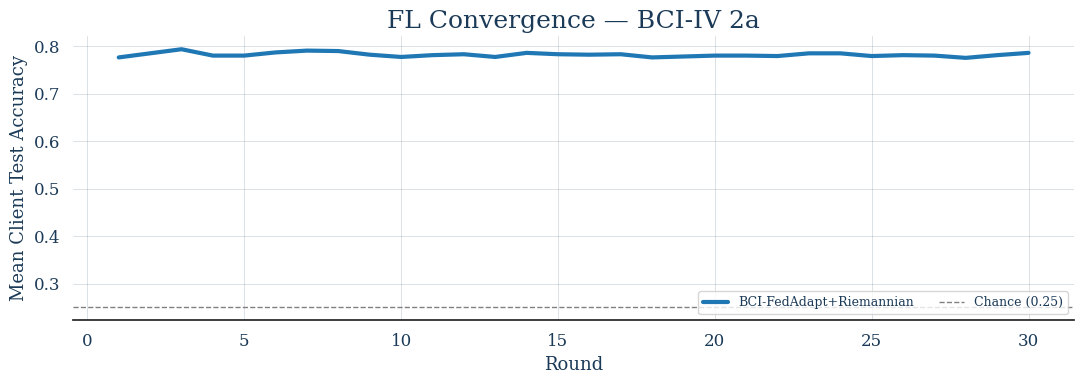

Saved: /mnt/user-data/outputs/flower_convergence_2a.png


In [16]:
plot_convergence(results_2a, CFG_2A, 'BCI-IV 2a',
                '/mnt/user-data/outputs/flower_convergence_2a.png', STRATEGIES)

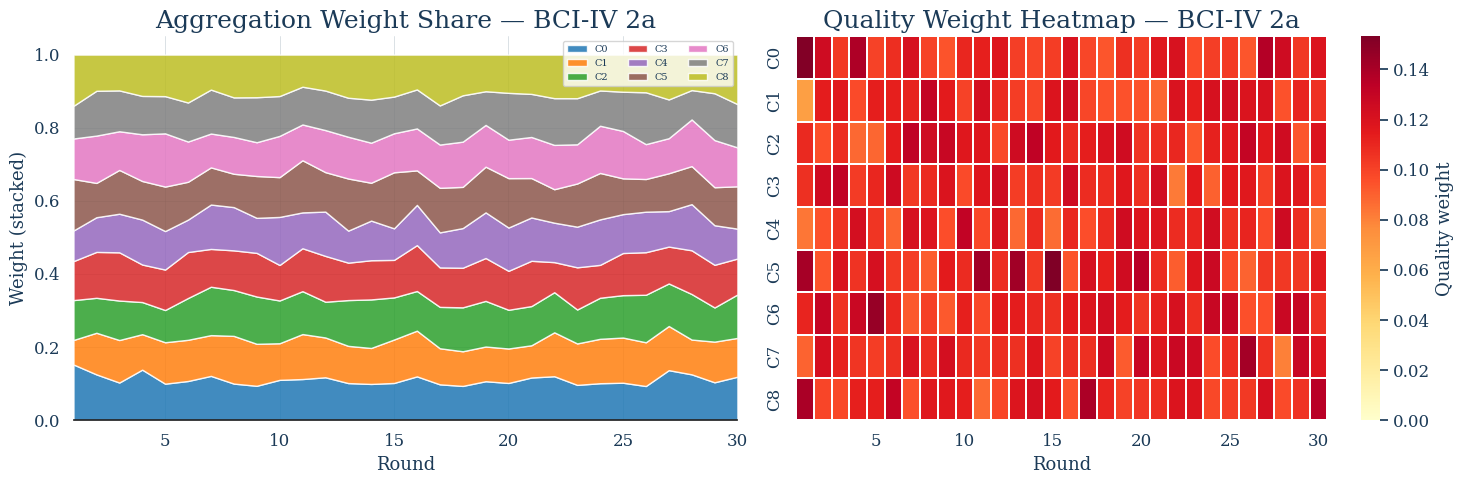

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
plot_quality_weights(results_2a, CFG_2A, 'BCI-IV 2a',
                    '/mnt/user-data/outputs/flower_quality_weights_2a.png')

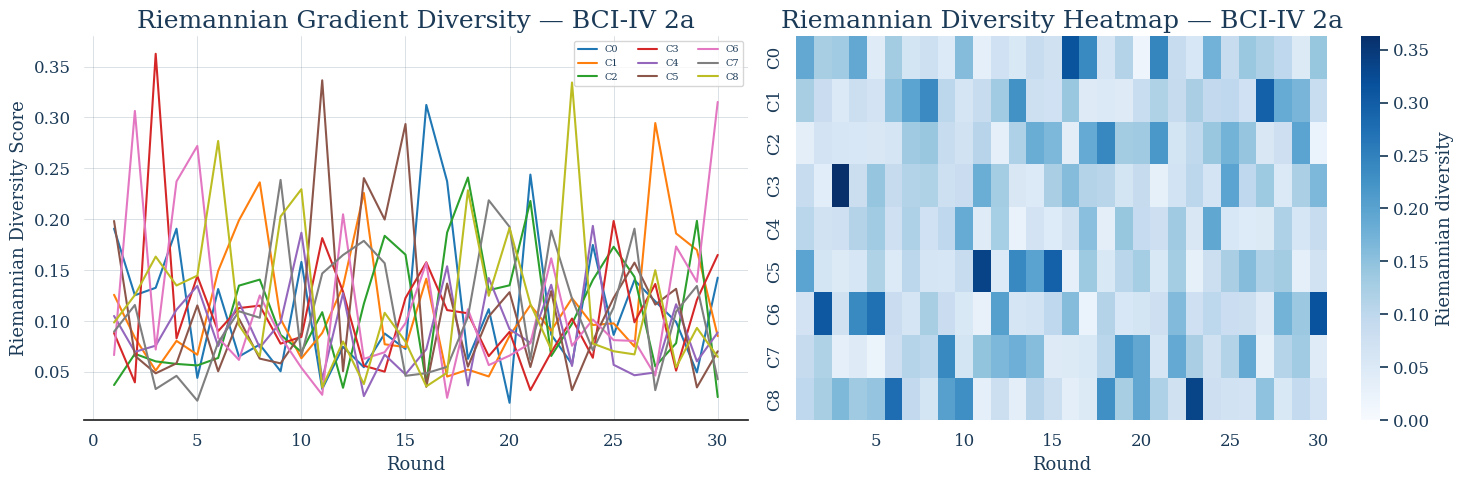

Saved: /mnt/user-data/outputs/flower_riemannian_diversity_2a.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
plot_riemannian_diversity(results_2a, CFG_2A, 'BCI-IV 2a',
                         '/mnt/user-data/outputs/flower_riemannian_diversity_2a.png')

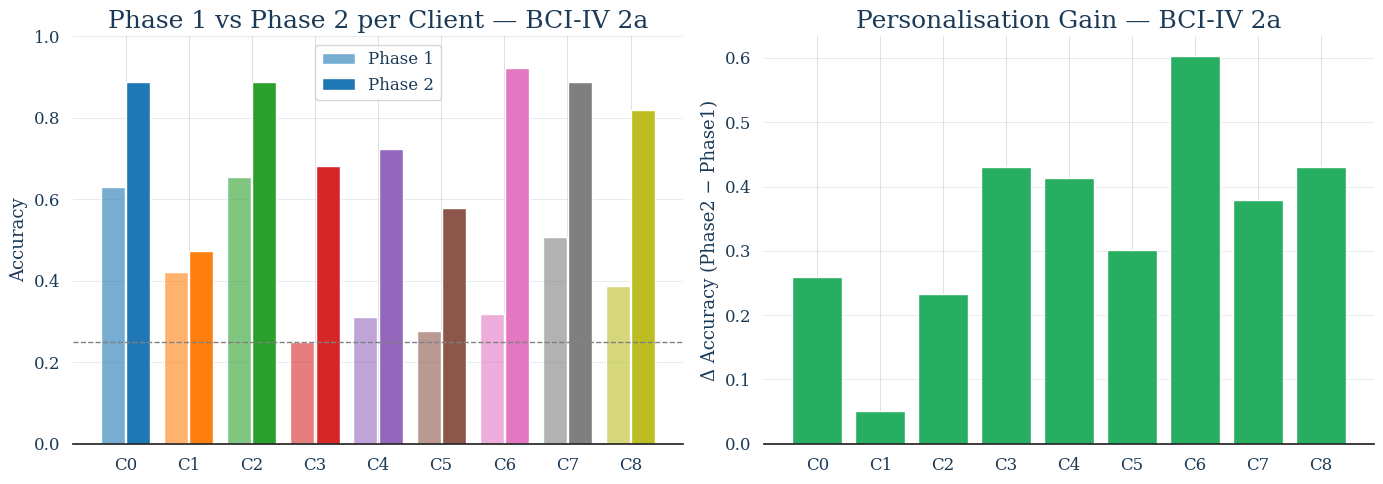

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
plot_personalisation_gain(results_2a, CFG_2A, 'BCI-IV 2a',
                          '/mnt/user-data/outputs/flower_personalisation_2a.png')

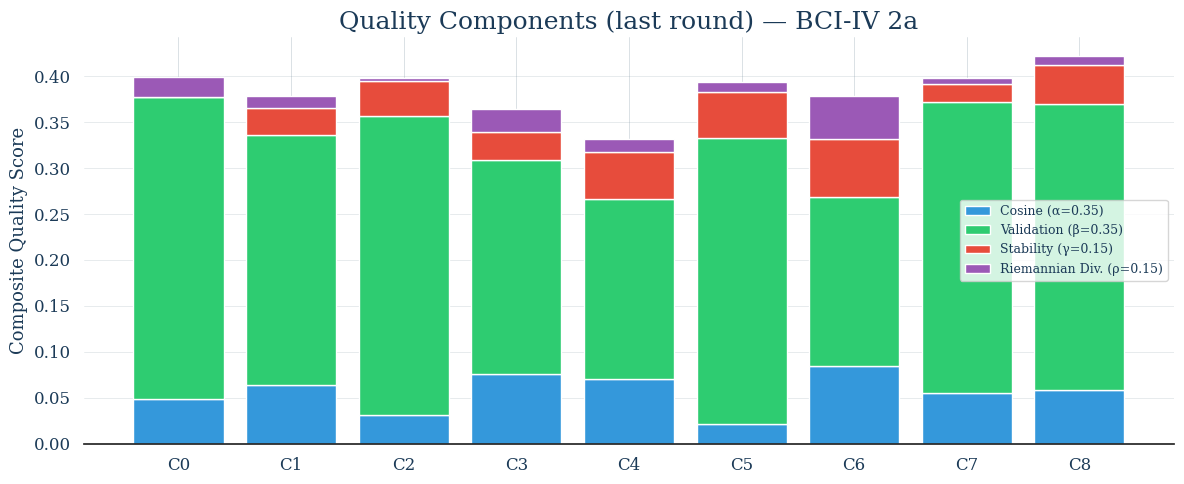

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
plot_quality_components(results_2a, CFG_2A, 'BCI-IV 2a',
                        '/mnt/user-data/outputs/flower_quality_components_2a.png')

In [21]:
# Final evaluation — BCI-IV 2a
final_2a = {}
for strat in STRATEGIES:
    ps  = results_2a[strat]['final_personal_states']
    acc, yl, yp = eval_global(None, CFG_2A, client_data_2a, personal_states=ps)
    final_2a[strat] = (acc, yl, yp)
    print(f'{strat}: {acc:.4f}')
best_2a = max(final_2a, key=lambda s: final_2a[s][0])

BCI-FedAdapt+Riemannian: 0.7625


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


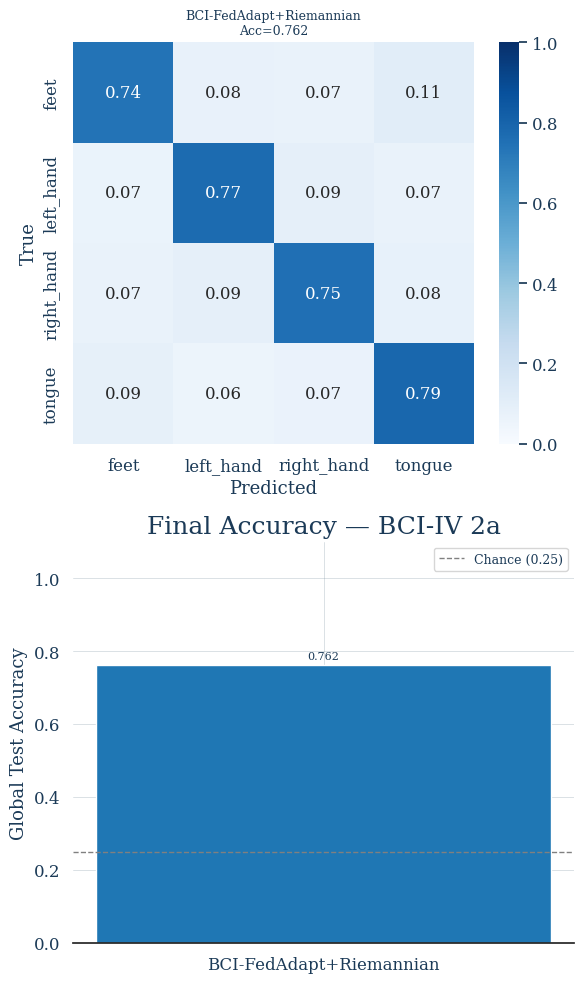

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
plot_eval(final_2a, STRATEGIES, CFG_2A, CLASS_NAMES_2A,
          'BCI-IV 2a', '/mnt/user-data/outputs/flower_bci_iv_2a')

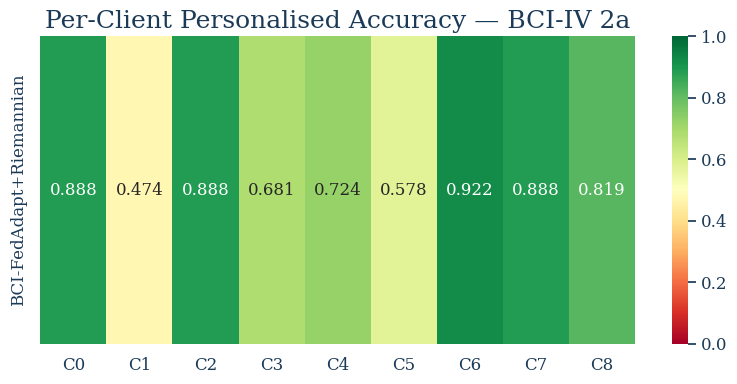

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
plot_per_client_heatmap(results_2a, STRATEGIES, CFG_2A, client_data_2a,
                        'BCI-IV 2a', '/mnt/user-data/outputs/flower_per_client_2a.png')

In [24]:
print_summary(final_2a, STRATEGIES, CFG_2A, results_2a, 'BCI-IV 2a', best_2a)
_, yl, yp = final_2a[best_2a]
print(classification_report(yl, yp, target_names=CLASS_NAMES_2A))


  SUMMARY — BCI-IV 2a
  BCI-FedAdapt+Riemannian           Acc=0.7625  P1=0.7864  P2=0.7625  Δchance=+0.5125  ← best

              precision    recall  f1-score   support

        feet       0.77      0.74      0.75       261
   left_hand       0.77      0.77      0.77       261
  right_hand       0.76      0.75      0.76       261
      tongue       0.75      0.79      0.77       261

    accuracy                           0.76      1044
   macro avg       0.76      0.76      0.76      1044
weighted avg       0.76      0.76      0.76      1044



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Three-Way Evaluation — BCI-IV 2a

In [25]:
# Subject-independent 2a -- v4: inject averaged BN stats + averaged personal weights
si_accs_2a = eval_subject_independent(
    CFG_2A, client_data_2a,
    results_2a['BCI-FedAdapt+Riemannian']['final_ndarrays'],
    bn_stat_store=results_2a['BCI-FedAdapt+Riemannian']['bn_stat_store'],
    bn_stat_idx=results_2a['BCI-FedAdapt+Riemannian']['bn_stat_idx'],
    personal_store=results_2a['BCI-FedAdapt+Riemannian']['personal_store'],
    personal_idx=results_2a['BCI-FedAdapt+Riemannian']['personal_idx'])


  [SI] Averaged BN stats from 9 clients (24 buffers)
  [SI] Averaged personal weights from 9 clients (8 tensors)
  SI Client 00: 0.3362


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SI Client 01: 0.3534


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SI Client 02: 0.3707


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SI Client 07: 0.2845


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SI Client 08: 0.3190
  Mean subject-independent: 0.3170


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
# Subject-dependent: train from scratch per subject, no FL
sd_accs_2a = eval_subject_dependent(CFG_2A, client_data_2a, n_epochs=100)

  SD Client 00: 0.9224


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SD Client 01: 0.6724


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SD Client 02: 0.9483


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SD Client 07: 0.9397


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SD Client 08: 0.8879
  Mean subject-dependent: 0.8305


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


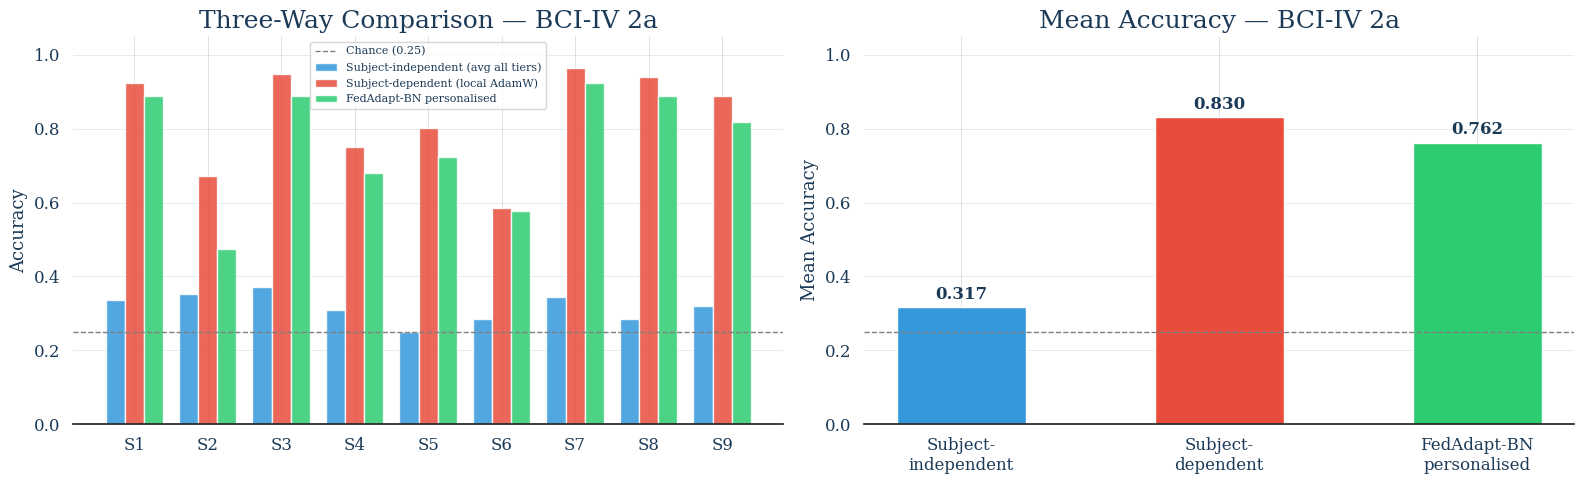

  Three-way — BCI-IV 2a
  SI (avg all tiers) : 0.3170
  SD (local AdamW)   : 0.8305
  FL personalised    : 0.7625
  FL-SI: +0.4454  FL-SD: -0.0680


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
# FL personalised: Phase 2 results (already computed above)
fl_accs_2a = results_2a['BCI-FedAdapt+Riemannian']['personal_accs_after']

plot_three_way_comparison(
    si_accs_2a, sd_accs_2a, fl_accs_2a,
    CFG_2A, 'BCI-IV 2a',
    '/mnt/user-data/outputs/three_way_2a.png')

---
# Part B — BCI-IV 2b  (9 subjects, 2-class Motor Imagery)

In [28]:
client_data_2b, N_TIMES_2B, CLASSES_2B = load_and_preprocess(CFG_2B)
CFG_2B['n_times'] = N_TIMES_2B
CLASS_NAMES_2B = [str(c) for c in CLASSES_2B]
print(f'\nBCI-IV 2b — {len(client_data_2b)} clients, {N_TIMES_2B} time points')

2026-03-29 15:39:23,867 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading BCI-IV 2b [Riemannian alignment] ...


100%|█████████████████████████████████████| 34.2M/34.2M [00:00<00:00, 47.5GB/s]
SHA256 hash of downloaded file: 0da6e77ab0dab5b4aa1d2d5a6a542ac02f6768d3b7a76b0abe896ec1cf259919
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 18.6M/18.6M [00:00<00:00, 27.9GB/s]
SHA256 hash of downloaded file: 5effd365ae3733402286f2eea6b1ce482680a9f9ffc55c0b41bc63061a0161b5
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
100%|████████████████████████████████

  Raw shape: (6520, 3, 1001)  Classes: ['left_hand', 'right_hand']
  Client 00: train=576  test=144
  Client 01: train=544  test=136
  Client 02: train=576  test=144


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 03: train=592  test=148
  Client 04: train=592  test=148
  Client 05: train=576  test=144
  Client 06: train=576  test=144
  Client 07: train=608  test=152
  Client 08: train=576  test=144

BCI-IV 2b — 9 clients, 1001 time points


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
# Run BCI-FedAdapt+Riemannian on BCI-IV 2b via Flower 1.9.0 simulation
results_2b = {}
results_2b['BCI-FedAdapt+Riemannian'] = run_flower_bci_fedadapt(CFG_2B, client_data_2b)

INFO :      Starting Flower simulation, config: num_rounds=30, no round_timeout



------------------------------------------------------------------------
  BCI-FedAdapt+Riemannian [Flower 1.9.0 | RA align | Riemannian agg]
  Phase 1: 30 federated rounds | Phase 2: 40 personalisation epochs
------------------------------------------------------------------------
  GPU detected: 2 physical  |  2.0 Ray GPU(s)  |  4 concurrent actors  →  0.50 GPU per client
  [Phase 1] Federated training with Riemannian aggregation ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-29 15:40:40,545	INFO worker.py:2007 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.19.2.2': 1.0, 'node:__internal_head__': 1.0, 'CPU': 4.0, 'object_store_memory': 8658042470.0, 'memory': 20202099098.0, 'GPU': 2.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :   

  Round   1  loss=0.6319  acc=0.7094  top=C1(0.151)  riem_div=0.1111


INFO :      aggregate_fit: received 9 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 9 clients (out of 9)
INFO :      aggregate_fit: received 9 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 9 clients (out of 9)
INFO :      aggregate_fit: received 9 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 9 clients (out of 9)
INFO :      aggregate_fit: received 9 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 6]
INFO :      configure_fit: strategy sampled 9 clients (out of 9)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 07: before=0.7895  after=0.8224  Δ=+0.0329


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Client 08: before=0.6042  after=0.8264  Δ=+0.2222

  Phase1 final: 0.7293  Phase2 final: 0.7617  (Δ=+0.0324)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Analysis — BCI-IV 2b

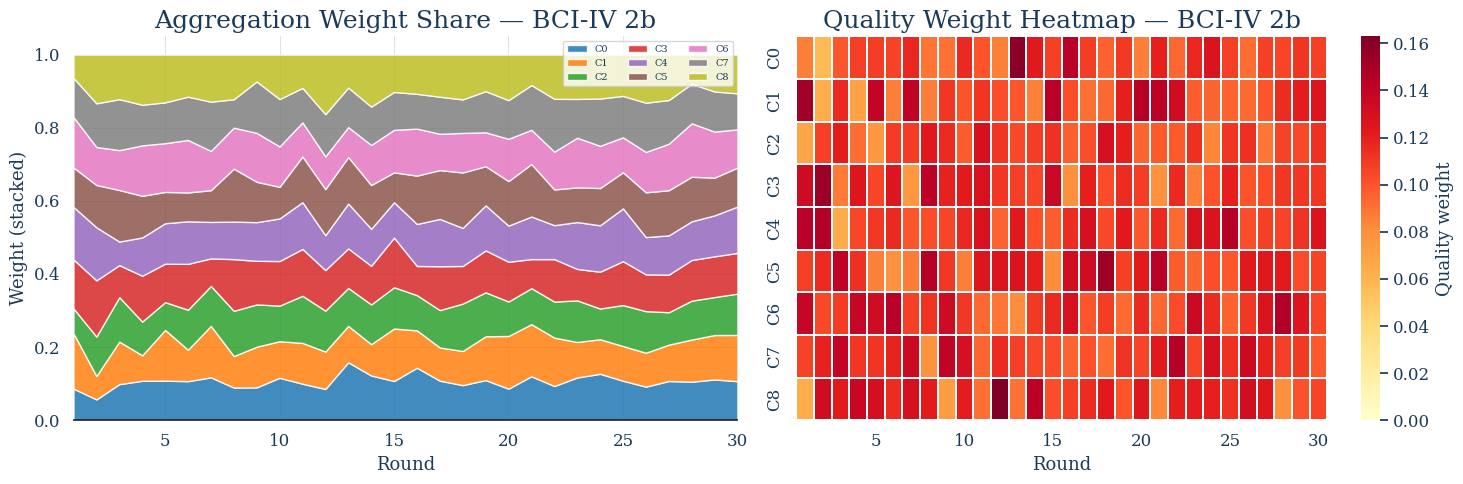

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


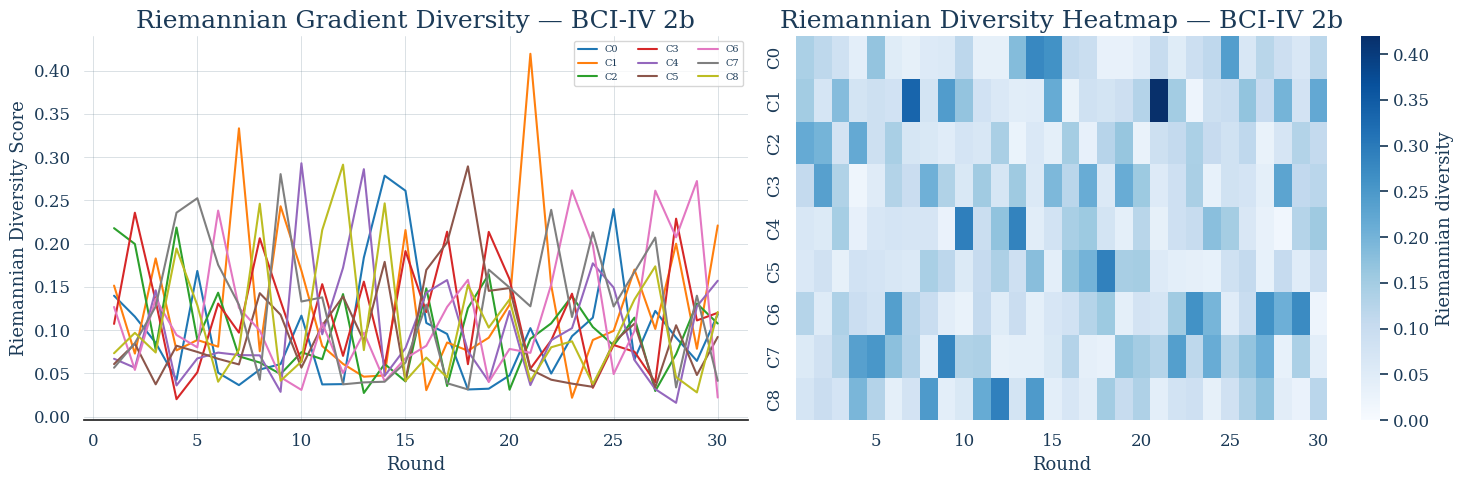

Saved: /mnt/user-data/outputs/flower_riemannian_diversity_2b.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


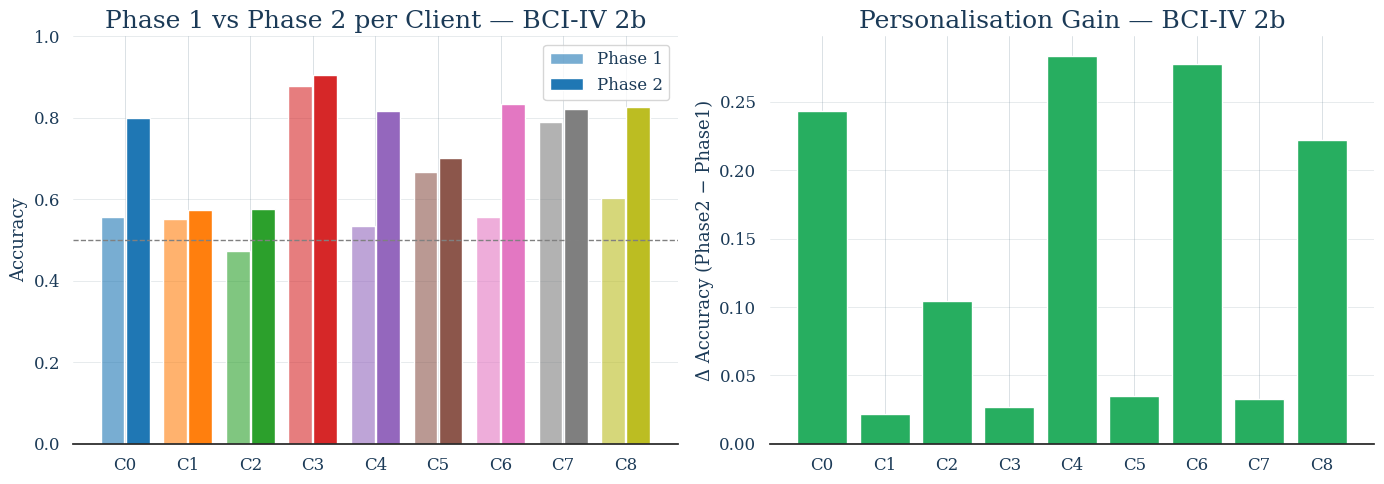

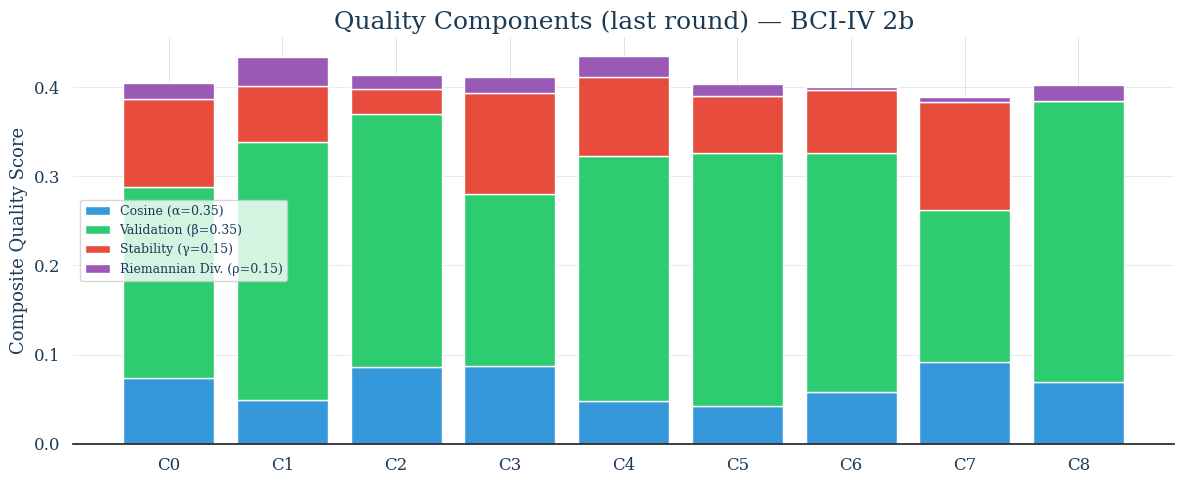

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
#plot_convergence(results_2b, CFG_2B, 'BCI-IV 2b',
  #              '/mnt/user-data/outputs/flower_convergence_2b.png', STRATEGIES)
plot_quality_weights(results_2b, CFG_2B, 'BCI-IV 2b',
                     '/mnt/user-data/outputs/flower_quality_weights_2b.png')
plot_riemannian_diversity(results_2b, CFG_2B, 'BCI-IV 2b',
                          '/mnt/user-data/outputs/flower_riemannian_diversity_2b.png')
plot_personalisation_gain(results_2b, CFG_2B, 'BCI-IV 2b',
                          '/mnt/user-data/outputs/flower_personalisation_2b.png')
plot_quality_components(results_2b, CFG_2B, 'BCI-IV 2b',
                        '/mnt/user-data/outputs/flower_quality_components_2b.png')

BCI-FedAdapt+Riemannian: 0.7638


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


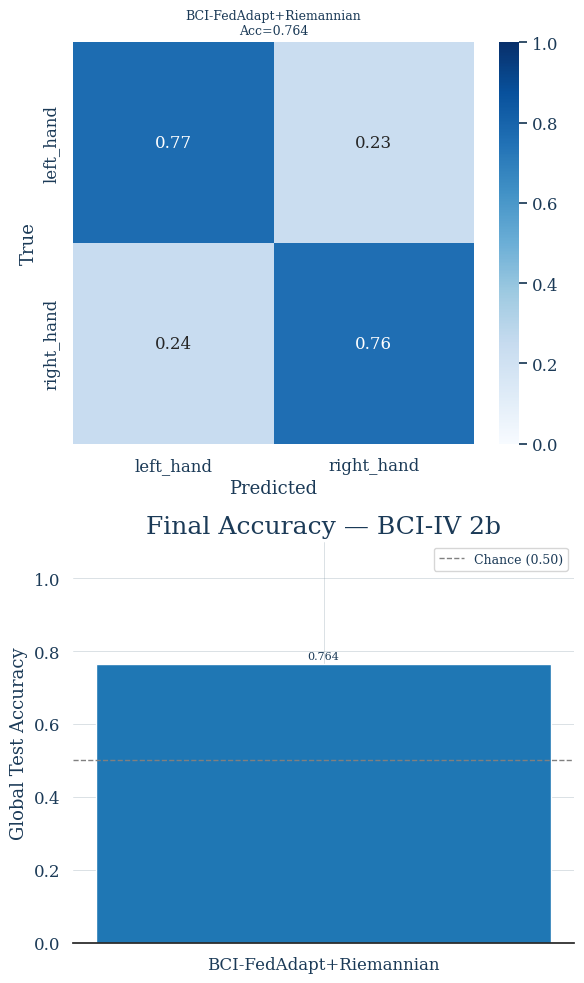

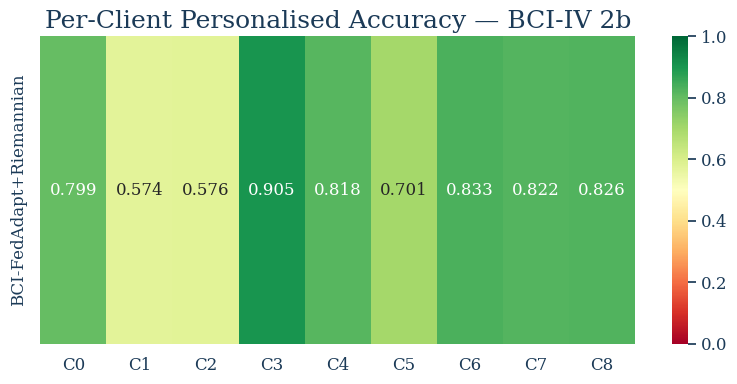


  SUMMARY — BCI-IV 2b
  BCI-FedAdapt+Riemannian           Acc=0.7638  P1=0.7293  P2=0.7617  Δchance=+0.2638  ← best

              precision    recall  f1-score   support

   left_hand       0.76      0.77      0.76       652
  right_hand       0.77      0.76      0.76       652

    accuracy                           0.76      1304
   macro avg       0.76      0.76      0.76      1304
weighted avg       0.76      0.76      0.76      1304



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
# Final evaluation — BCI-IV 2b
final_2b = {}
for strat in STRATEGIES:
    ps  = results_2b[strat]['final_personal_states']
    acc, yl, yp = eval_global(None, CFG_2B, client_data_2b, personal_states=ps)
    final_2b[strat] = (acc, yl, yp)
    print(f'{strat}: {acc:.4f}')
best_2b = max(final_2b, key=lambda s: final_2b[s][0])

plot_eval(final_2b, STRATEGIES, CFG_2B, CLASS_NAMES_2B,
          'BCI-IV 2b', '/mnt/user-data/outputs/flower_bci_iv_2b')
plot_per_client_heatmap(results_2b, STRATEGIES, CFG_2B, client_data_2b,
                        'BCI-IV 2b', '/mnt/user-data/outputs/flower_per_client_2b.png')
print_summary(final_2b, STRATEGIES, CFG_2B, results_2b, 'BCI-IV 2b', best_2b)
_, yl, yp = final_2b[best_2b]
print(classification_report(yl, yp, target_names=CLASS_NAMES_2B))

### Three-Way Evaluation — BCI-IV 2b

  [SI] Averaged BN stats from 9 clients (24 buffers)
  [SI] Averaged personal weights from 9 clients (8 tensors)
  SI Client 00: 0.5694


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SI Client 01: 0.5074


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SI Client 02: 0.5347


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SD Client 07: 0.8158


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  SD Client 08: 0.8194
  Mean subject-dependent: 0.7507


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


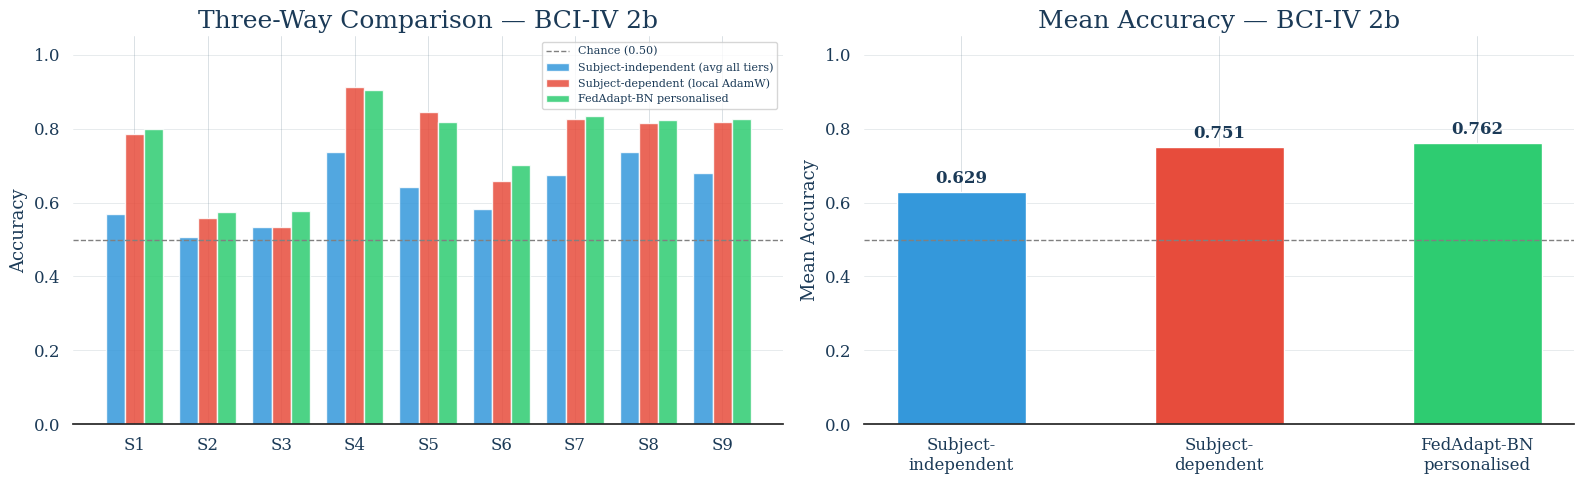

  Three-way — BCI-IV 2b
  SI (avg all tiers) : 0.6294
  SD (local AdamW)   : 0.7507
  FL personalised    : 0.7617
  FL-SI: +0.1323  FL-SD: +0.0110


In [32]:
si_accs_2b = eval_subject_independent(
    CFG_2B, client_data_2b,
    results_2b['BCI-FedAdapt+Riemannian']['final_ndarrays'],
    bn_stat_store=results_2b['BCI-FedAdapt+Riemannian']['bn_stat_store'],
    bn_stat_idx=results_2b['BCI-FedAdapt+Riemannian']['bn_stat_idx'],
    personal_store=results_2b['BCI-FedAdapt+Riemannian']['personal_store'],
    personal_idx=results_2b['BCI-FedAdapt+Riemannian']['personal_idx'])
sd_accs_2b = eval_subject_dependent(CFG_2B, client_data_2b, n_epochs=100)
fl_accs_2b = results_2b['BCI-FedAdapt+Riemannian']['personal_accs_after']

plot_three_way_comparison(
    si_accs_2b, sd_accs_2b, fl_accs_2b,
    CFG_2B, 'BCI-IV 2b',
    '/mnt/user-data/outputs/three_way_2b.png')


---
# Cross-Dataset Comparison & Riemannian Manifold Summary

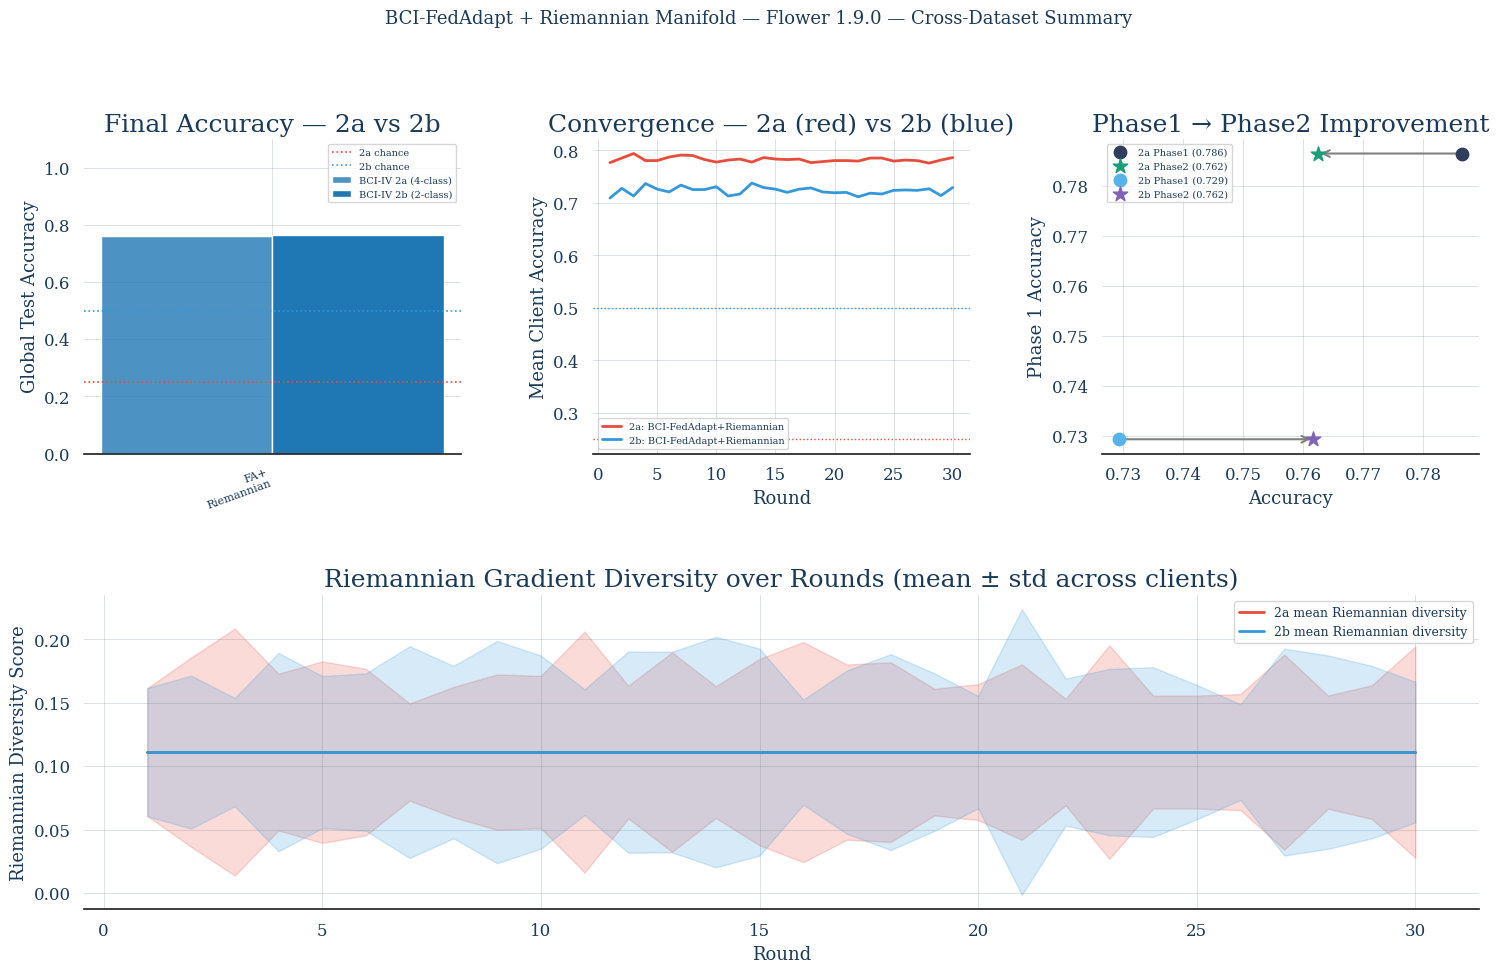

Cross-dataset summary saved.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
# Cross-dataset comparison with Riemannian diversity overlay
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
x   = np.arange(len(STRATEGIES))
w   = 0.35
accs_2a = [final_2a[s][0] for s in STRATEGIES]
accs_2b = [final_2b[s][0] for s in STRATEGIES]
pal     = sns.color_palette('tab10', len(STRATEGIES))
ax0.bar(x-w/2, accs_2a, w, label='BCI-IV 2a (4-class)',
        color=[p+(0.8,) for p in pal], edgecolor='white')
ax0.bar(x+w/2, accs_2b, w, label='BCI-IV 2b (2-class)',
        color=pal, edgecolor='white')
ax0.axhline(0.25, ls=':', color='#e74c3c', lw=1.2, label='2a chance')
ax0.axhline(0.50, ls=':', color='#3498db', lw=1.2, label='2b chance')
ax0.set_xticks(x)
ax0.set_xticklabels([s.replace('BCI-FedAdapt+', 'FA+\n') for s in STRATEGIES],
                    rotation=20, ha='right', fontsize=8)
ax0.set_ylabel('Global Test Accuracy'); ax0.set_ylim(0, 1.1)
ax0.set_title('Final Accuracy — 2a vs 2b'); ax0.legend(fontsize=7)

ax1 = fig.add_subplot(gs[0, 1])
rounds = np.arange(1, CFG_2A['num_rounds'] + 1)
for tag, res, col in [('2a', results_2a, '#e74c3c'), ('2b', results_2b, '#3498db')]:
    for s in STRATEGIES:
        ax1.plot(rounds, res[s]['history'], color=col, lw=2, label=f'{tag}: {s}')
ax1.axhline(0.25, ls=':', color='#e74c3c', lw=1)
ax1.axhline(0.50, ls=':', color='#3498db', lw=1)
ax1.set_xlabel('Round'); ax1.set_ylabel('Mean Client Accuracy')
ax1.set_title('Convergence — 2a (red) vs 2b (blue)')
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
for (tag, results, cfg_) in [('2a', results_2a, CFG_2A), ('2b', results_2b, CFG_2B)]:
    for s in STRATEGIES:
        p1 = results[s]['mean_acc_phase1']
        p2 = results[s]['mean_acc_phase2']
        ax2.annotate('', xy=(p2, p1), xytext=(p1, p1),
                     arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
        ax2.scatter([p1], [p1], marker='o', s=80, zorder=5,
                    label=f'{tag} Phase1 ({p1:.3f})')
        ax2.scatter([p2], [p1], marker='*', s=120, zorder=5,
                    label=f'{tag} Phase2 ({p2:.3f})')
ax2.set_xlabel('Accuracy'); ax2.set_ylabel('Phase 1 Accuracy')
ax2.set_title('Phase1 → Phase2 Improvement')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, :])
key = STRATEGIES[0]
for (tag, results, col) in [('2a', results_2a, '#e74c3c'), ('2b', results_2b, '#3498db')]:
    diag_log  = results[key]['diag_log']
    riem_mean = np.array([d['riemann'].mean() for d in diag_log])
    riem_std  = np.array([d['riemann'].std()  for d in diag_log])
    ax3.plot(rounds, riem_mean, color=col, lw=2,
             label=f'{tag} mean Riemannian diversity')
    ax3.fill_between(rounds, riem_mean - riem_std, riem_mean + riem_std,
                     alpha=0.2, color=col)
ax3.set_xlabel('Round'); ax3.set_ylabel('Riemannian Diversity Score')
ax3.set_title('Riemannian Gradient Diversity over Rounds (mean ± std across clients)')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.suptitle('BCI-FedAdapt + Riemannian Manifold — Flower 1.9.0 — Cross-Dataset Summary',
             fontsize=13, y=1.01)
plt.savefig('/mnt/user-data/outputs/flower_cross_dataset_riemannian.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Cross-dataset summary saved.')

In [34]:
# Final comprehensive summary
print('\n' + '='*78)
print('  BCI-FedAdapt-BN + Riemannian Manifold — FINAL RESULTS')
print('='*78)

for ds_tag, final_, cfg_, results_, si_, sd_, fl_ in [
    ('BCI-IV 2a (4-class)', final_2a, CFG_2A, results_2a,
     si_accs_2a, sd_accs_2a, fl_accs_2a),
    ('BCI-IV 2b (2-class)', final_2b, CFG_2B, results_2b,
     si_accs_2b, sd_accs_2b, fl_accs_2b),
]:
    chance = 1.0 / cfg_['n_classes']
    print(f'\n  {ds_tag}')
    print(f'  {"─"*60}')
    for s in STRATEGIES:
        acc = final_[s][0]
        p1  = results_[s]['mean_acc_phase1']
        p2  = results_[s]['mean_acc_phase2']
        print(f'  Strategy: {s}')
        print(f'    Phase 1 (global FL model) : {p1:.4f}')
        print(f'    Phase 2 (personalised)    : {p2:.4f}  Δ = {p2-p1:+.4f}')
        print(f'    eval_global               : {acc:.4f}  Δchance = {acc-chance:+.4f}')
    print(f'  ─── Three-way comparison ───────────────────')
    print(f'  Subject-independent  (SI)  : {np.mean(si_):.4f}')
    print(f'  Subject-dependent    (SD)  : {np.mean(sd_):.4f}')
    print(f'  FedAdapt-BN personalised   : {np.mean(fl_):.4f}')
    print(f'  FL vs SI : {np.mean(fl_)-np.mean(si_):+.4f}  | FL vs SD : {np.mean(fl_)-np.mean(sd_):+.4f}')

print('\n' + '='*78)


  BCI-FedAdapt-BN + Riemannian Manifold — FINAL RESULTS

  BCI-IV 2a (4-class)
  ────────────────────────────────────────────────────────────
  Strategy: BCI-FedAdapt+Riemannian
    Phase 1 (global FL model) : 0.7864
    Phase 2 (personalised)    : 0.7625  Δ = -0.0239
    eval_global               : 0.7625  Δchance = +0.5125
  ─── Three-way comparison ───────────────────
  Subject-independent  (SI)  : 0.3170
  Subject-dependent    (SD)  : 0.8305
  FedAdapt-BN personalised   : 0.7625
  FL vs SI : +0.4454  | FL vs SD : -0.0680

  BCI-IV 2b (2-class)
  ────────────────────────────────────────────────────────────
  Strategy: BCI-FedAdapt+Riemannian
    Phase 1 (global FL model) : 0.7293
    Phase 2 (personalised)    : 0.7617  Δ = +0.0324
    eval_global               : 0.7638  Δchance = +0.2638
  ─── Three-way comparison ───────────────────
  Subject-independent  (SI)  : 0.6294
  Subject-dependent    (SD)  : 0.7507
  FedAdapt-BN personalised   : 0.7617
  FL vs SI : +0.1323  | FL vs SD : +